# California Housing Price Prediction
## Full Data Science Pipeline: EDA → Preprocessing → Modeling → Evaluation

---

**Objective:** Predict the median house value for California districts using demographic and geographic features.

**Why this matters:** Understanding which factors drive housing prices helps urban planners, real estate investors, and policymakers make data-driven decisions. A predictive model can estimate property values where appraisals are unavailable.

---

### How this notebook is organized

We will walk through the **entire data science workflow** step by step. Each section starts with an explanation of *what* we're about to do and *why* it matters. Libraries are imported only when they are first needed, so you always see which tool is being used for which job.

| Step | Purpose |
|---|---|
| 1. Data Loading & Inspection | Understand shape, types, and quality of the raw data |
| 2. Exploratory Data Analysis (EDA) | Discover patterns, distributions, and relationships |
| 3. Data Cleaning & Preprocessing | Handle missing values, encode categoricals, engineer features |
| 4. Train/Test Split | Create held-out data to evaluate generalization |
| 5. Model Training (Multiple Algorithms) | Compare many models to find the best approach |
| 6. Model Evaluation & Comparison | Use metrics to objectively select the winner |
| 7. Final Model Deep Dive | Analyze the best model's predictions and feature importance |

---
## 1. Data Loading & First Inspection

The very first thing we do in any data science project is **load the data and take a look at it**. This might seem obvious, but this step is critical because it tells us:

- **How big is the dataset?** — Thousands of rows? Millions? This affects which algorithms we can use and how long training will take.
- **What columns do we have?** — What features are available? Are they numbers, categories, text?
- **Are there obvious problems?** — Missing values, weird data types, unexpected ranges.

Think of it like opening a box and checking what's inside before you start building something with it. You wouldn't start assembling furniture without first checking all the parts are there.

We need **pandas** here — it's the standard Python library for working with tabular data (think of it as Excel on steroids).

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')  # Keep the output clean for presentation

df = pd.read_csv(r'../data/raw/housing.csv')

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
df.head(10)

Dataset shape: 20,640 rows x 10 columns
Memory usage: 2.7 MB



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


### What are we looking at?

Each row represents a **census block group** (a district) in California. The columns are:

| Column | What it means |
|---|---|
| `longitude`, `latitude` | Where the district is on the map |
| `housing_median_age` | How old the houses are (in years) |
| `total_rooms`, `total_bedrooms` | Total count of rooms/bedrooms in the entire district |
| `population` | How many people live in the district |
| `households` | How many separate households |
| `median_income` | Median household income (in tens of thousands of dollars) |
| `median_house_value` | **This is what we want to predict** — the median house price |
| `ocean_proximity` | A text label describing how close the district is to the ocean |

Now let's look at the **data types and check for missing values**. This is like doing an inventory check — do we have all the data we expect, or are there gaps?

In [2]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


### Statistical summary

Now we look at the **basic statistics** for each numeric column — min, max, mean, standard deviation, and percentiles. This is important because:

- The **min/max** tell us the range of each feature. If the min is negative when it shouldn't be (e.g., negative bedrooms), that's a data quality issue.
- The **mean vs median (50%)** tells us if data is skewed. When the mean is much higher than the median, it means a few very large values are pulling the average up.
- The **standard deviation** tells us how spread out the values are. Features with huge spread may need special treatment.
- Comparing the **75th percentile to the max** reveals outliers — if the max is 10x the 75th percentile, there are extreme values.

In [3]:
df.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


### Let's check for missing values and inspect the categorical feature

Missing data is one of the most common problems in real-world datasets. Before we can do anything else, we need to know:
- **Which columns have missing values?**
- **How much is missing?** — 1% missing is very different from 50% missing.

We also want to look at `ocean_proximity` — it's our only non-numeric column, so we need to understand what categories exist and how they're distributed.

In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
print(missing_df[missing_df['Missing Count'] > 0])
if missing_df['Missing Count'].sum() == 0:
    print('  No missing values found!')
print()

# Categorical column
print('=== Ocean Proximity (our only categorical feature) ===')
print(df['ocean_proximity'].value_counts())
print()

# Target variable
print(f'=== Target: median_house_value ===')
print(f'Range: ${df["median_house_value"].min():,.0f} - ${df["median_house_value"].max():,.0f}')
print(f'Median: ${df["median_house_value"].median():,.0f}')

=== Missing Values ===
                Missing Count  Missing %
total_bedrooms            207        1.0

=== Ocean Proximity (our only categorical feature) ===
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

=== Target: median_house_value ===
Range: $14,999 - $500,001
Median: $179,700


---
## 2. Exploratory Data Analysis (EDA)

Now that we have a basic understanding of our data, it's time for the most important step in any data science project: **Exploratory Data Analysis**.

EDA is like being a detective. We're going to look at the data from every angle to uncover:

- **Distributions** — What does each feature look like? Is it bell-shaped, skewed, or has multiple peaks? This affects which models work well.
- **Relationships** — Which features are correlated with house prices? Which features are correlated with *each other* (which could cause problems)?
- **Outliers** — Are there extreme values that could mislead our models?
- **Patterns** — Are there geographic or categorical trends we can exploit?

**Skipping EDA is like driving blindfolded** — you might get somewhere, but probably not where you want.

For visualization, we'll use **matplotlib** (the foundational plotting library) and **seaborn** (which makes prettier statistical plots on top of matplotlib). We also need **numpy** for numerical operations.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up presentation-ready plots: large fonts, high resolution, clean look.
# This way every chart we make can be directly screenshotted for PowerPoint.
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

print('Visualization libraries loaded. All plots are set to presentation quality.')

Visualization libraries loaded. All plots are set to presentation quality.


### 2.1 Understanding the Target Variable

The first thing we should look at is the **variable we're trying to predict**: `median_house_value`. We need to understand its distribution because:

1. **If it's heavily skewed**, some models (like linear regression) may struggle. We might need to apply a transformation (like taking the logarithm).
2. **If there are artificial caps or floors**, those are data collection artifacts, not real patterns — and they can confuse models.
3. **The shape of the distribution** tells us what kind of errors to expect — a wide distribution means there's a lot of variation to explain.

We'll look at both a **histogram** (shows the shape of the distribution) and a **box plot** (highlights outliers and quartiles).

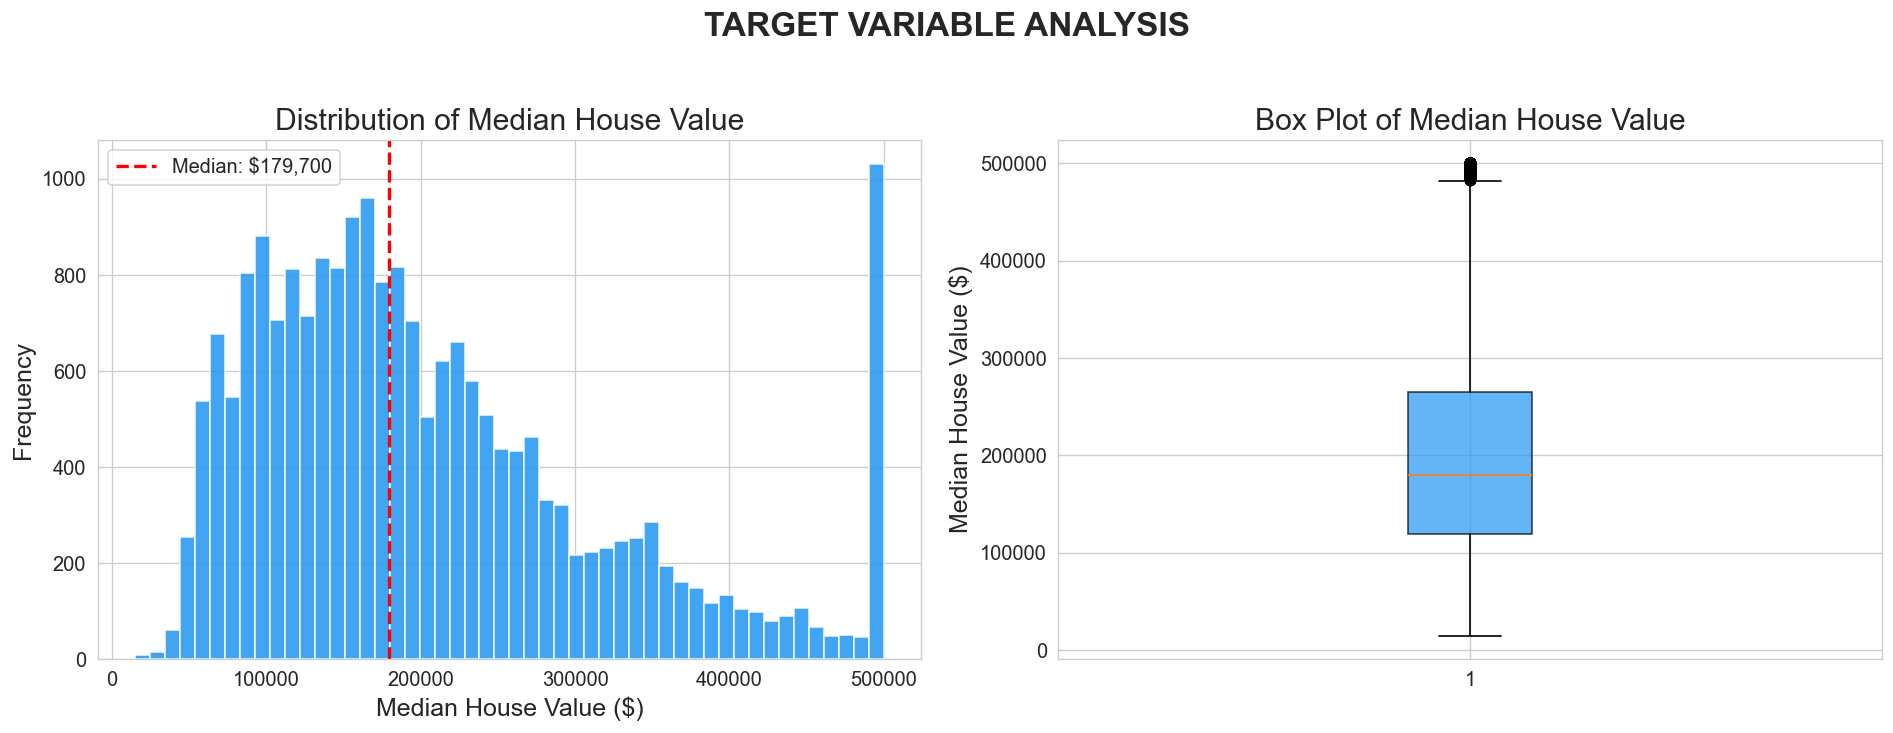

Values at the cap ($500,001): 965 rows (4.7%)
These are CAPPED values from the census — the real values could be higher.
This is a data limitation we should keep in mind: the model will struggle to predict very expensive homes accurately.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df['median_house_value'], bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(df['median_house_value'].median(), color='red', linestyle='--', linewidth=2,
                label=f'Median: ${df["median_house_value"].median():,.0f}')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(df['median_house_value'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.7))
axes[1].set_title('Box Plot of Median House Value')
axes[1].set_ylabel('Median House Value ($)')

plt.suptitle('TARGET VARIABLE ANALYSIS', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Check for value capping
cap_count = (df['median_house_value'] == df['median_house_value'].max()).sum()
print(f'Values at the cap (${df["median_house_value"].max():,.0f}): {cap_count} rows ({cap_count/len(df)*100:.1f}%)')
print('These are CAPPED values from the census — the real values could be higher.')
print('This is a data limitation we should keep in mind: the model will struggle to predict very expensive homes accurately.')

### 2.2 How Are the Features Distributed?

Now we're going to look at every numeric feature individually. Why does this matter?

- **Skewed features** (long tail on one side) can dominate distance-based models like KNN — because one feature with a huge range will overshadow all the others in distance calculations.
- **Different scales** are a problem: `median_income` ranges from 0 to 15, while `population` ranges from 0 to 35,000. Without scaling, a model would think population is 2,000x more important just because the numbers are bigger.
- **Multimodal distributions** (multiple peaks) suggest there are hidden sub-groups in the data — maybe urban vs rural districts behave differently.

The red dashed line shows the mean. When the mean is far from the center, the data is skewed.

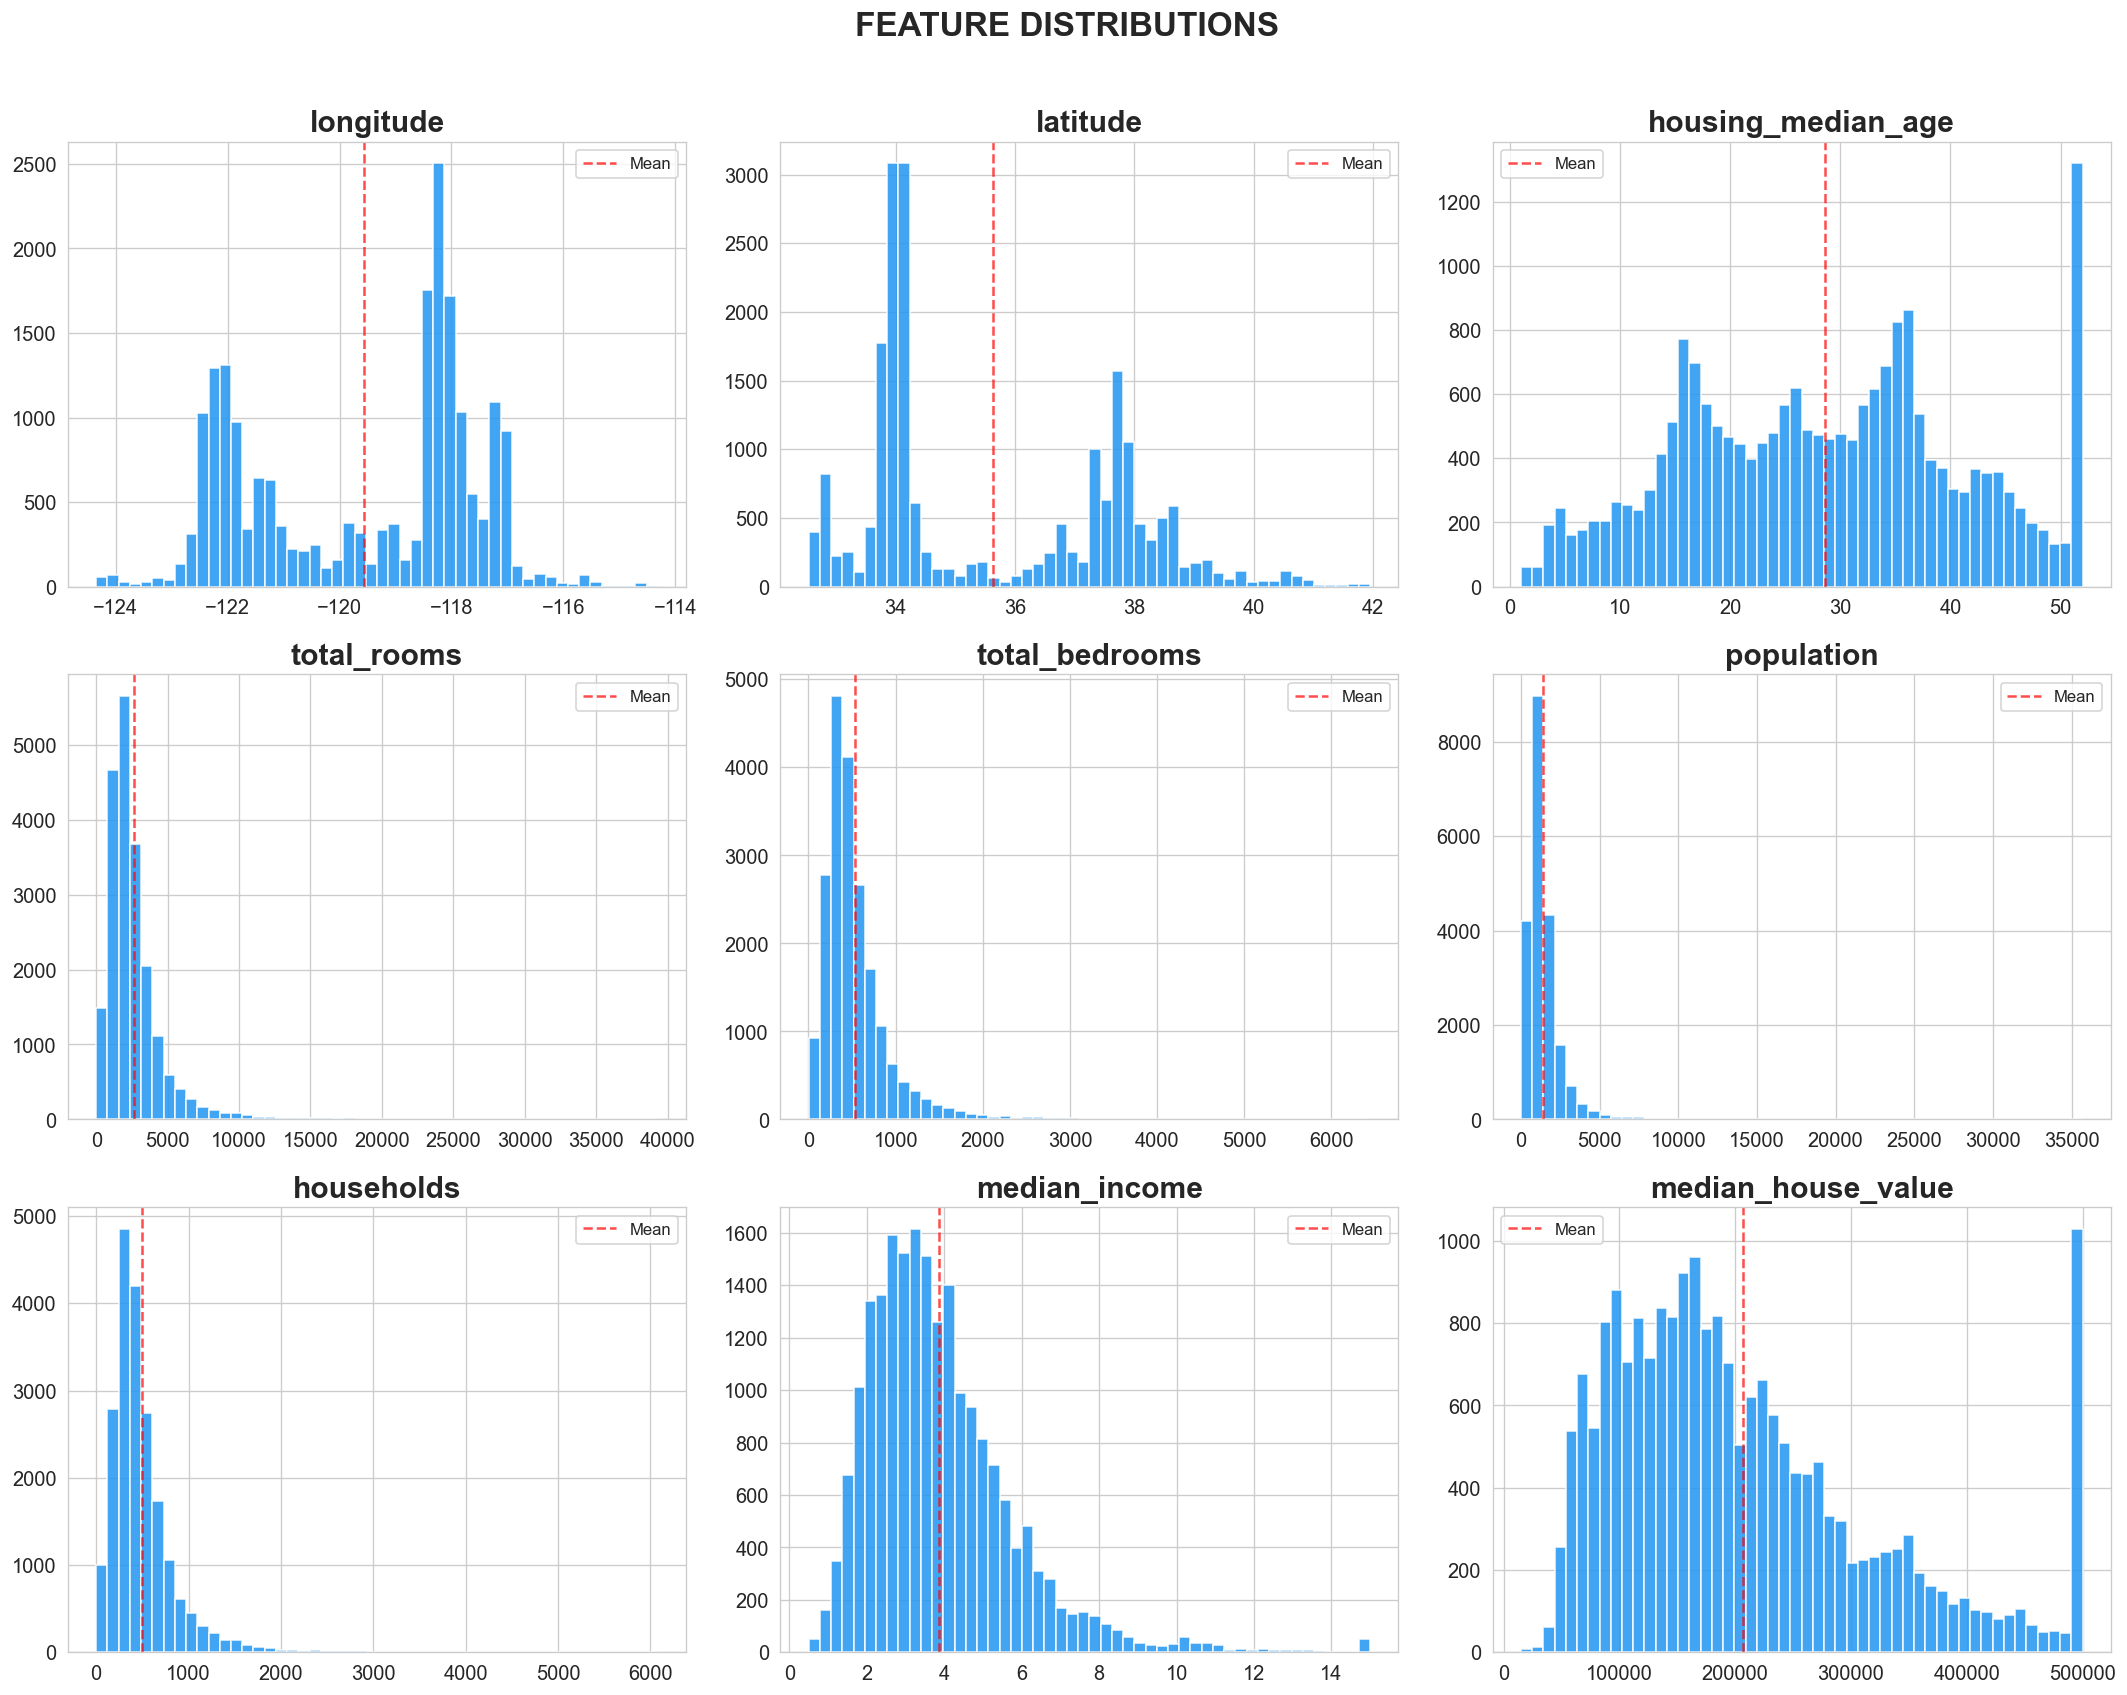

Observations:
  - total_rooms, total_bedrooms, population, households are all RIGHT-SKEWED
    (most districts are small, but a few are very large)
  - median_income looks roughly bell-shaped — good for linear models
  - housing_median_age has a spike at 52 — likely another cap in the data


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', alpha=0.7, label='Mean')
    axes[i].legend(fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('FEATURE DISTRIBUTIONS', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Observations:')
print('  - total_rooms, total_bedrooms, population, households are all RIGHT-SKEWED')
print('    (most districts are small, but a few are very large)')
print('  - median_income looks roughly bell-shaped — good for linear models')
print('  - housing_median_age has a spike at 52 — likely another cap in the data')

### 2.3 Which Features Are Related to House Prices? (Correlation Analysis)

Now we want to answer the key question: **which features actually help predict house value?**

We use **Pearson correlation**, which measures the linear relationship between two variables on a scale from -1 to +1:
- **+1** = perfect positive relationship (when one goes up, the other always goes up)
- **0** = no linear relationship
- **-1** = perfect negative relationship (when one goes up, the other always goes down)

We're looking for two things:
1. **Strong correlation with the target** (`median_house_value`) — these features will be the most useful predictors.
2. **Strong correlation between features** (multicollinearity) — if two features carry the same information (like `total_rooms` and `total_bedrooms`), they're redundant. This can destabilize linear models because the model can't decide which one to use.

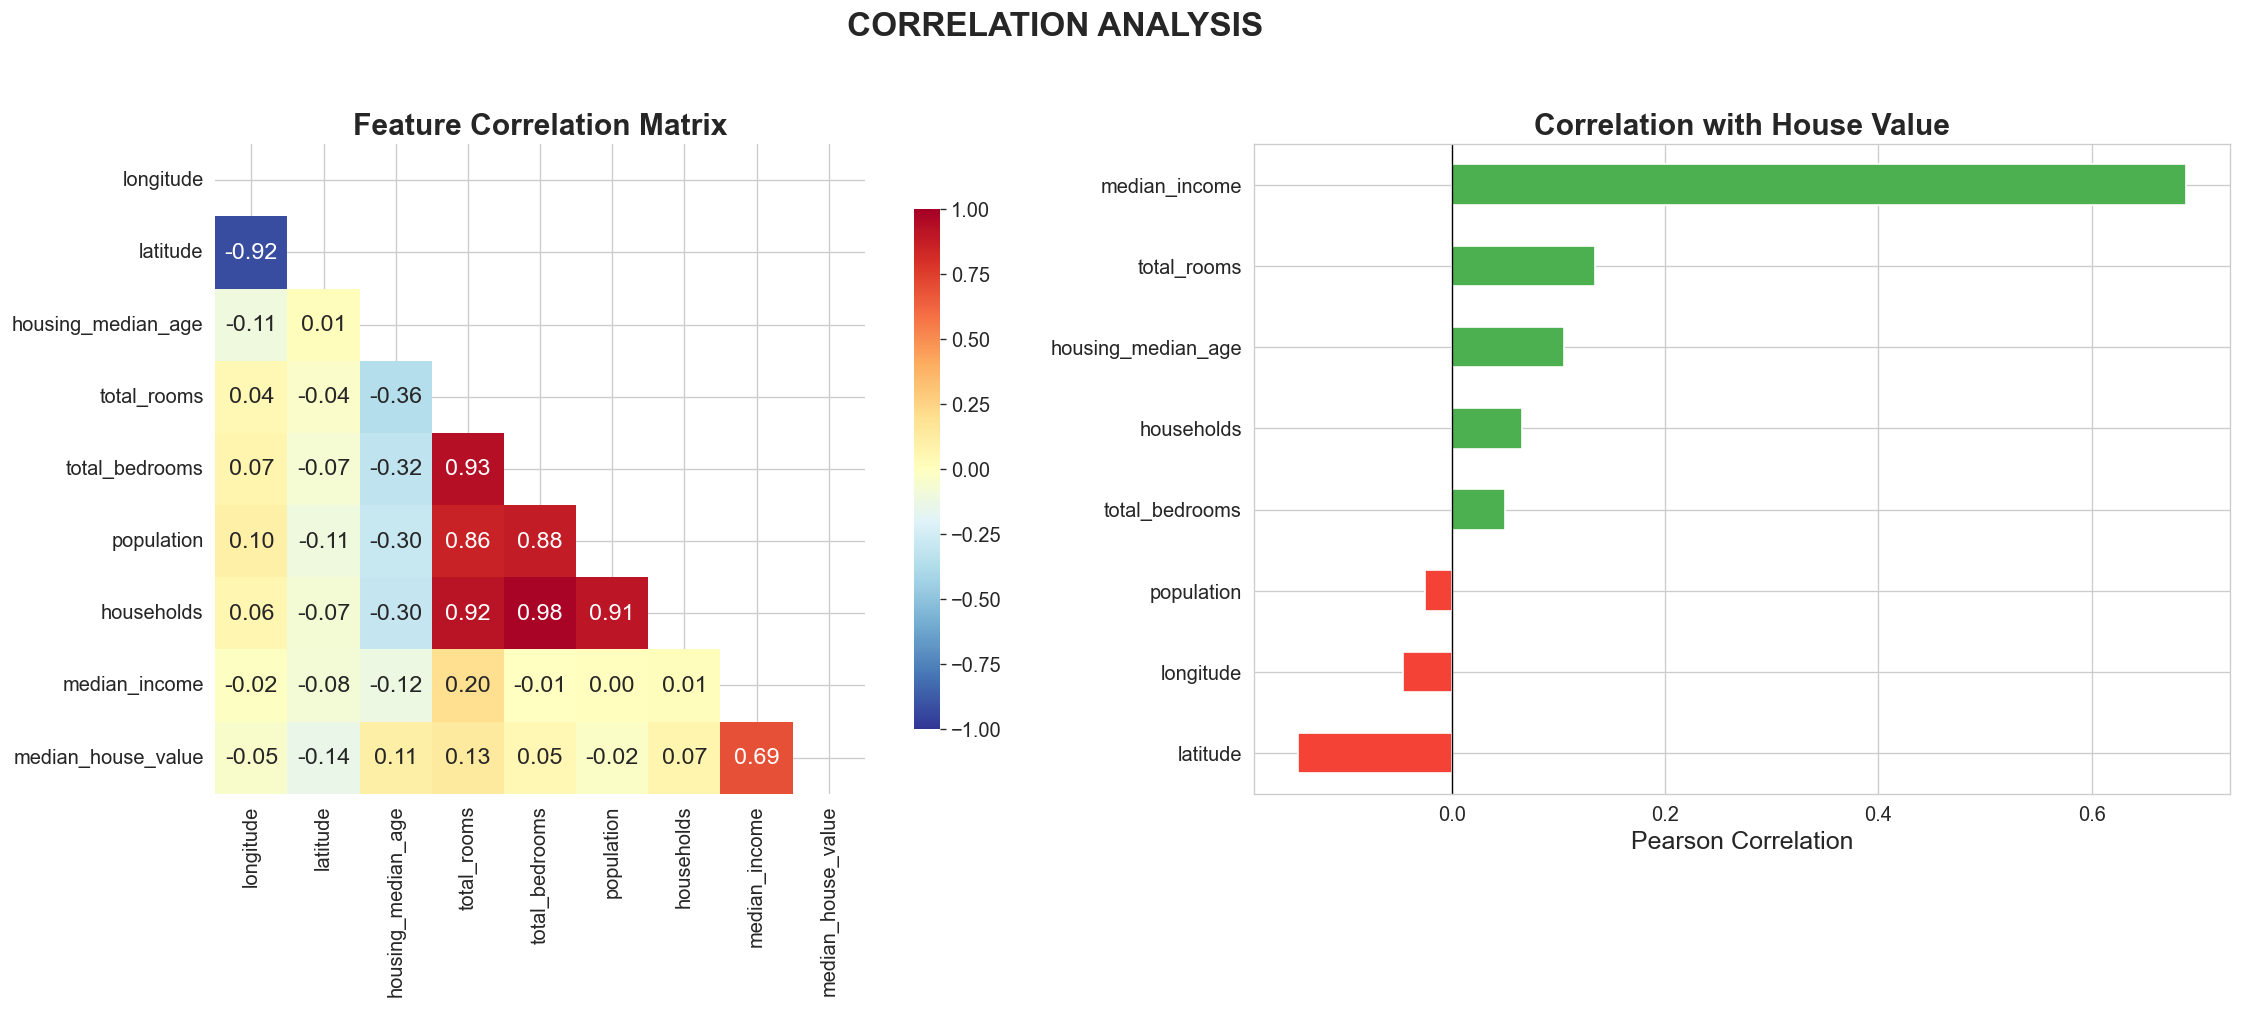

Key findings:
  STRONGEST predictor: median_income (r = 0.69)
    -> Higher income areas have more expensive houses. Makes intuitive sense.
  MULTICOLLINEARITY: total_rooms <-> total_bedrooms (r = 0.93)
    -> These two features are almost saying the same thing. We should be aware of this.
  MULTICOLLINEARITY: total_rooms <-> households (r = 0.92)
    -> More households = more rooms. Again, redundant information.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full correlation heatmap
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, ax=axes[0], vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')

# Correlation with target — bar chart
target_corr = corr['median_house_value'].drop('median_house_value').sort_values()
colors = ['#F44336' if v < 0 else '#4CAF50' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors, ax=axes[1], edgecolor='white')
axes[1].set_title('Correlation with House Value', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('CORRELATION ANALYSIS', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Key findings:')
print(f'  STRONGEST predictor: median_income (r = {corr["median_house_value"]["median_income"]:.2f})')
print(f'    -> Higher income areas have more expensive houses. Makes intuitive sense.')
print(f'  MULTICOLLINEARITY: total_rooms <-> total_bedrooms (r = {corr["total_rooms"]["total_bedrooms"]:.2f})')
print(f'    -> These two features are almost saying the same thing. We should be aware of this.')
print(f'  MULTICOLLINEARITY: total_rooms <-> households (r = {corr["total_rooms"]["households"]:.2f})')
print(f'    -> More households = more rooms. Again, redundant information.')

### 2.4 Where Are the Expensive Houses? (Geographic Analysis)

Real estate has a famous rule: **location, location, location**. Our dataset includes latitude and longitude, which lets us literally plot California on a map and color each district by its house value.

This is powerful because:
- It reveals **spatial patterns** that no correlation number can capture — clusters of expensive areas, coastal premiums, urban vs rural differences.
- It helps us verify that the data makes geographic sense (a sanity check).
- It gives stakeholders an immediately intuitive visual for the presentation.

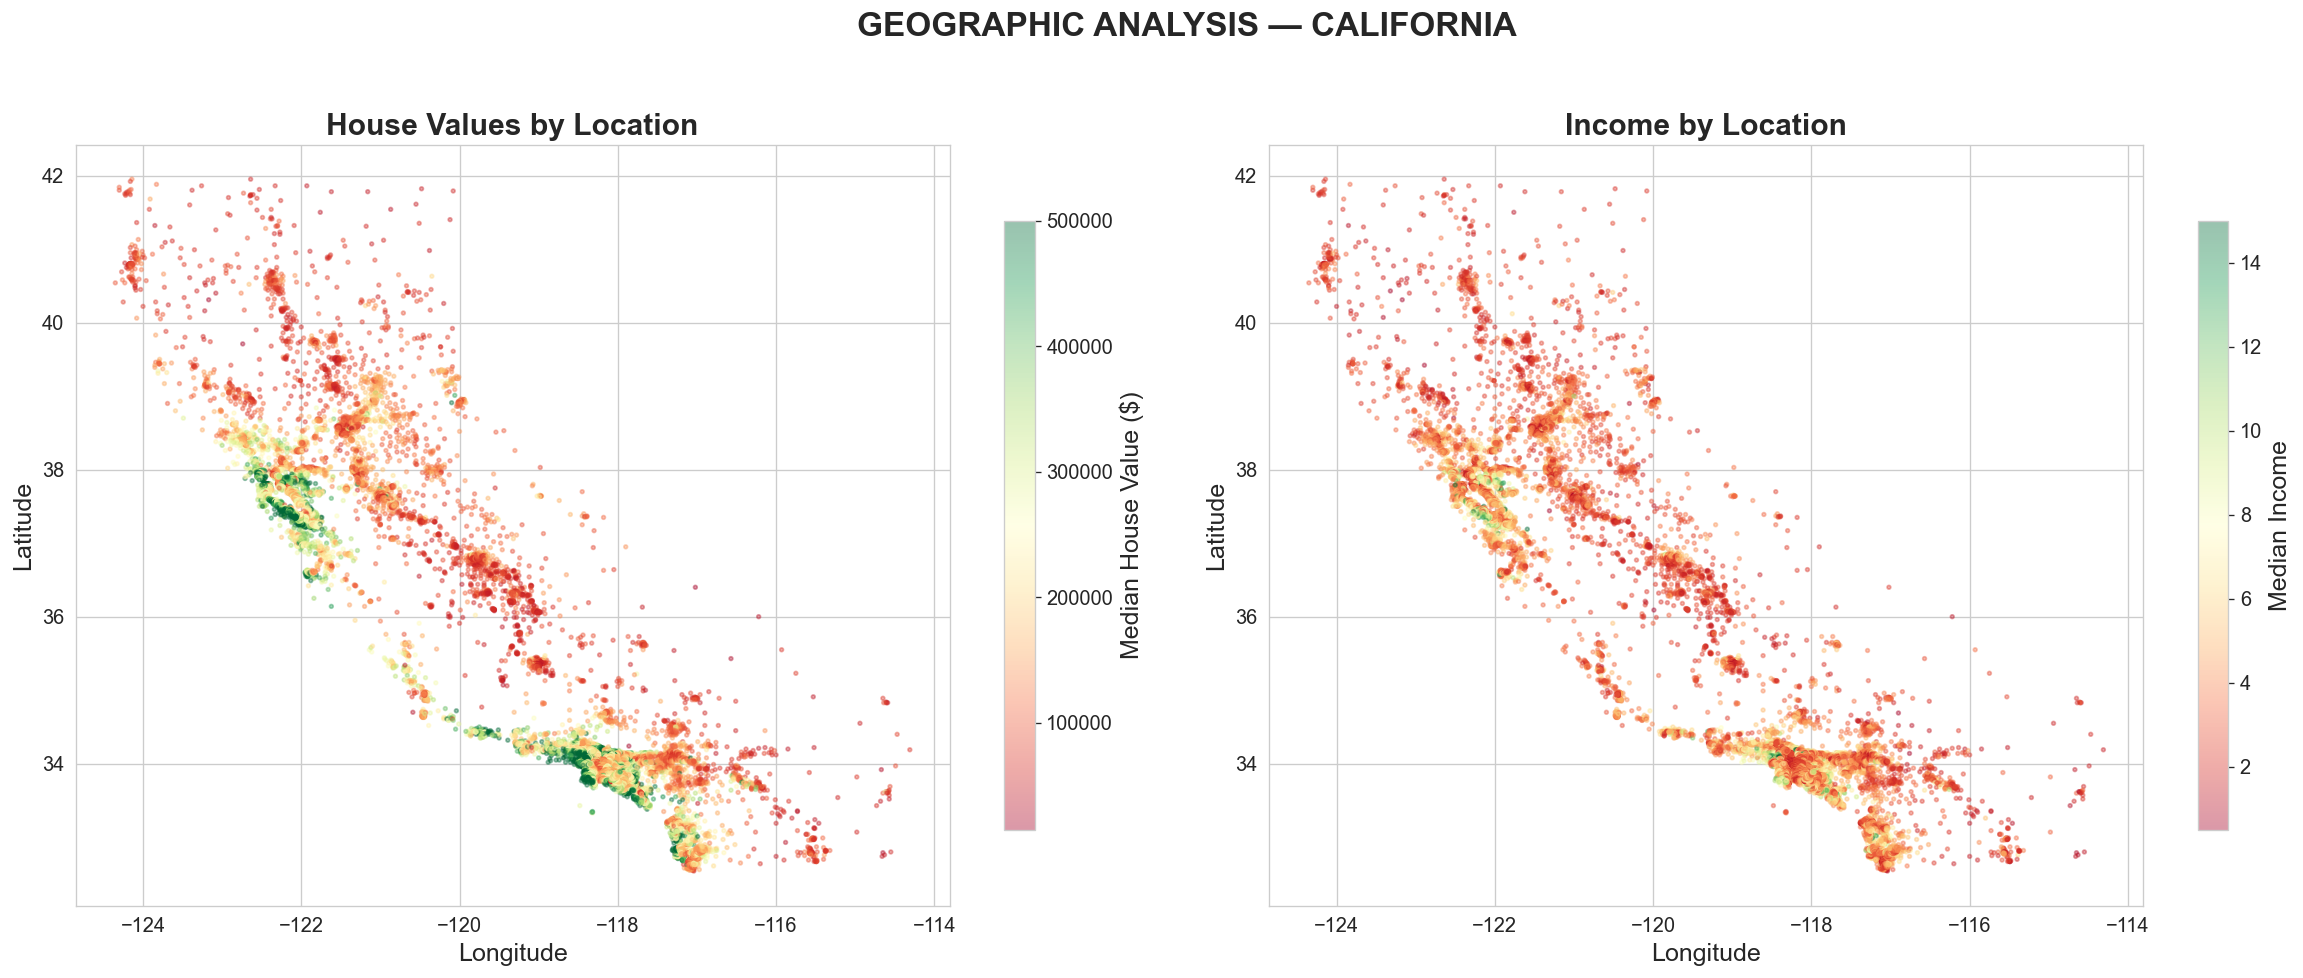

What we see:
  - Expensive houses cluster along the COAST, especially around San Francisco and Los Angeles.
  - Income follows a very similar pattern — confirming the strong income-price relationship.
  - Inland areas (Central Valley) are consistently cheaper.
  - This tells us that latitude/longitude carry real predictive information, not just noise.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Map colored by house value
scatter1 = axes[0].scatter(df['longitude'], df['latitude'],
                           c=df['median_house_value'], cmap='RdYlGn',
                           alpha=0.4, s=5)
plt.colorbar(scatter1, ax=axes[0], label='Median House Value ($)', shrink=0.8)
axes[0].set_title('House Values by Location', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Map colored by income
scatter2 = axes[1].scatter(df['longitude'], df['latitude'],
                           c=df['median_income'], cmap='RdYlGn',
                           alpha=0.4, s=5)
plt.colorbar(scatter2, ax=axes[1], label='Median Income', shrink=0.8)
axes[1].set_title('Income by Location', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('GEOGRAPHIC ANALYSIS — CALIFORNIA', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('What we see:')
print('  - Expensive houses cluster along the COAST, especially around San Francisco and Los Angeles.')
print('  - Income follows a very similar pattern — confirming the strong income-price relationship.')
print('  - Inland areas (Central Valley) are consistently cheaper.')
print('  - This tells us that latitude/longitude carry real predictive information, not just noise.')

### 2.5 Does Ocean Proximity Matter?

We have one categorical feature: `ocean_proximity`. Before we encode it for modeling, we need to check whether it actually carries useful information. Specifically:

- **How many districts are in each category?** If 99% of data is in one category, the feature won't help much.
- **Do house prices differ meaningfully across categories?** If INLAND and NEAR OCEAN have the same price distribution, the feature isn't adding value.

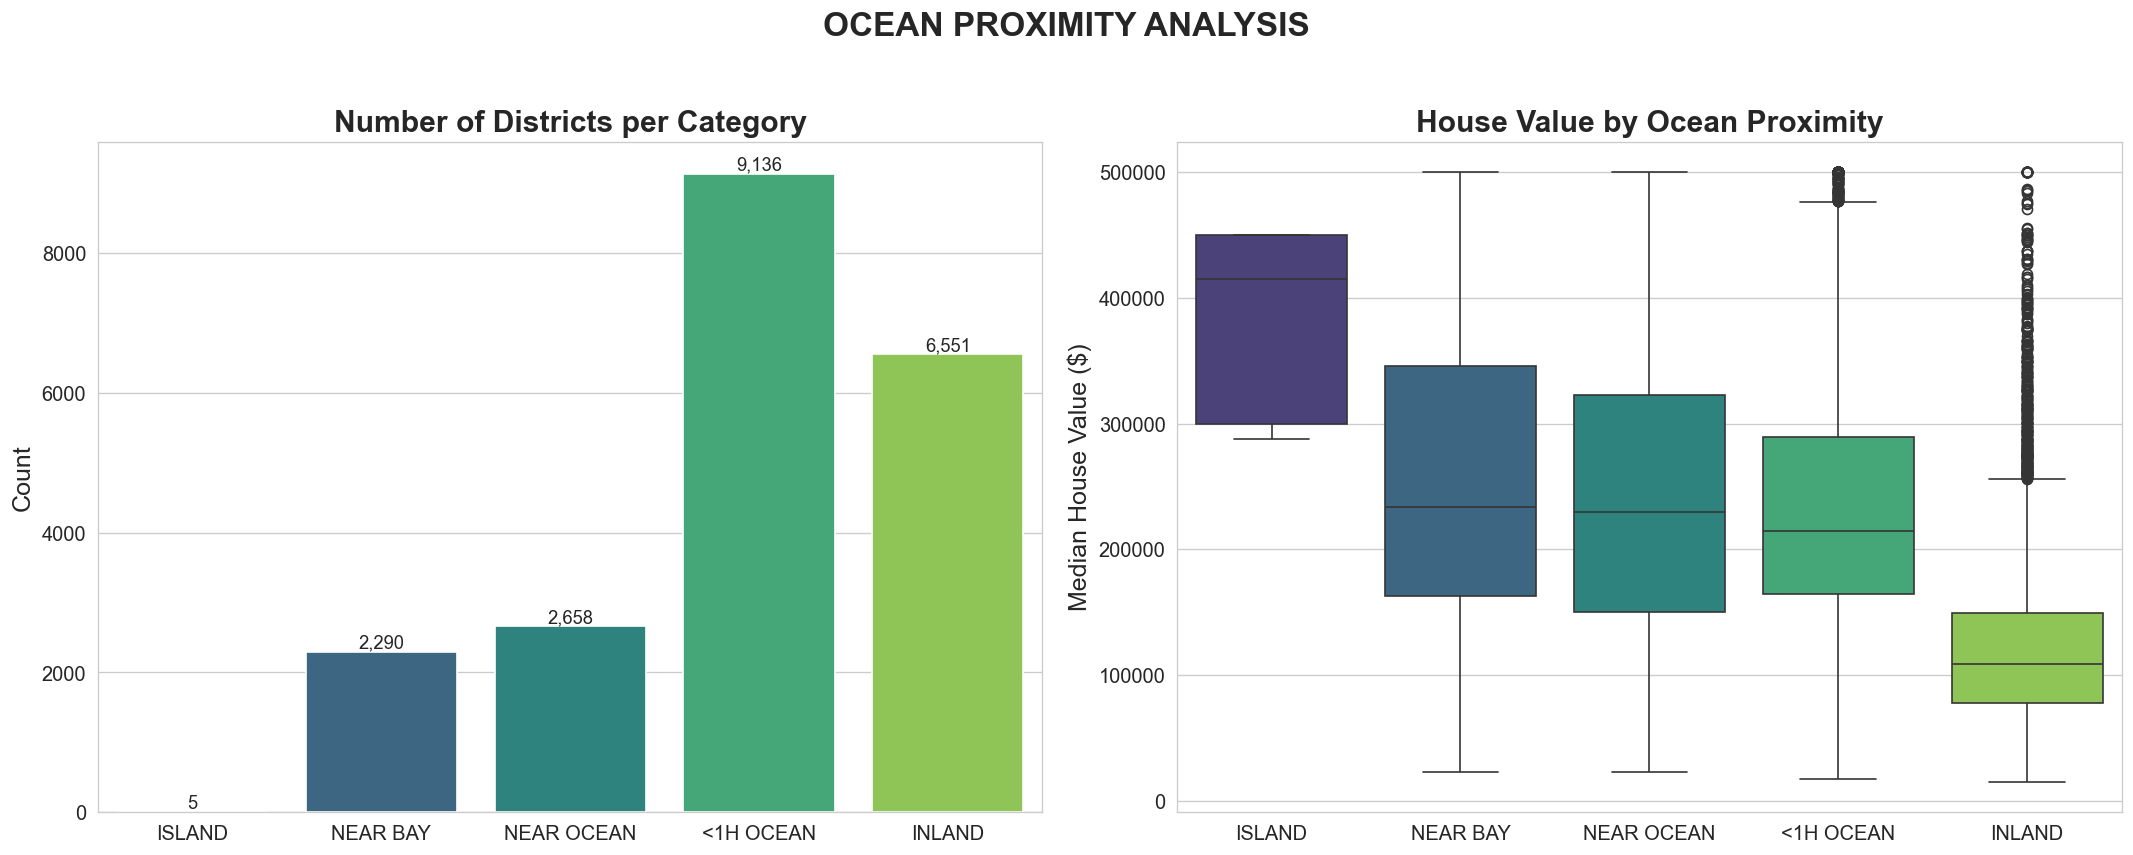

Median house value by category:
ocean_proximity
ISLAND        $414,700
NEAR BAY      $233,800
NEAR OCEAN    $229,450
<1H OCEAN     $214,850
INLAND        $108,500
Name: median_house_value, dtype: str

Conclusion: YES, ocean proximity matters a lot!
  - ISLAND districts are the most expensive (small sample though — only 5 districts).
  - NEAR BAY and NEAR OCEAN are significantly more expensive than INLAND.
  - This feature will definitely help our models.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

order = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).index

# Count per category
sns.countplot(data=df, x='ocean_proximity', order=order, ax=axes[0],
              palette='viridis', edgecolor='white')
axes[0].set_title('Number of Districts per Category', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# House value per category
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', order=order,
            ax=axes[1], palette='viridis')
axes[1].set_title('House Value by Ocean Proximity', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Median House Value ($)')

plt.suptitle('OCEAN PROXIMITY ANALYSIS', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Median house value by category:')
print(df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))
print()
print('Conclusion: YES, ocean proximity matters a lot!')
print('  - ISLAND districts are the most expensive (small sample though — only 5 districts).')
print('  - NEAR BAY and NEAR OCEAN are significantly more expensive than INLAND.')
print('  - This feature will definitely help our models.')

### 2.6 The Most Important Relationship: Income vs House Value

Our correlation analysis showed that `median_income` is the single strongest predictor (r = 0.69). Let's look at this relationship more carefully, because if our model can get this one relationship right, it's already doing most of the heavy lifting.

We'll also color the points by housing age to see if older vs newer areas behave differently.

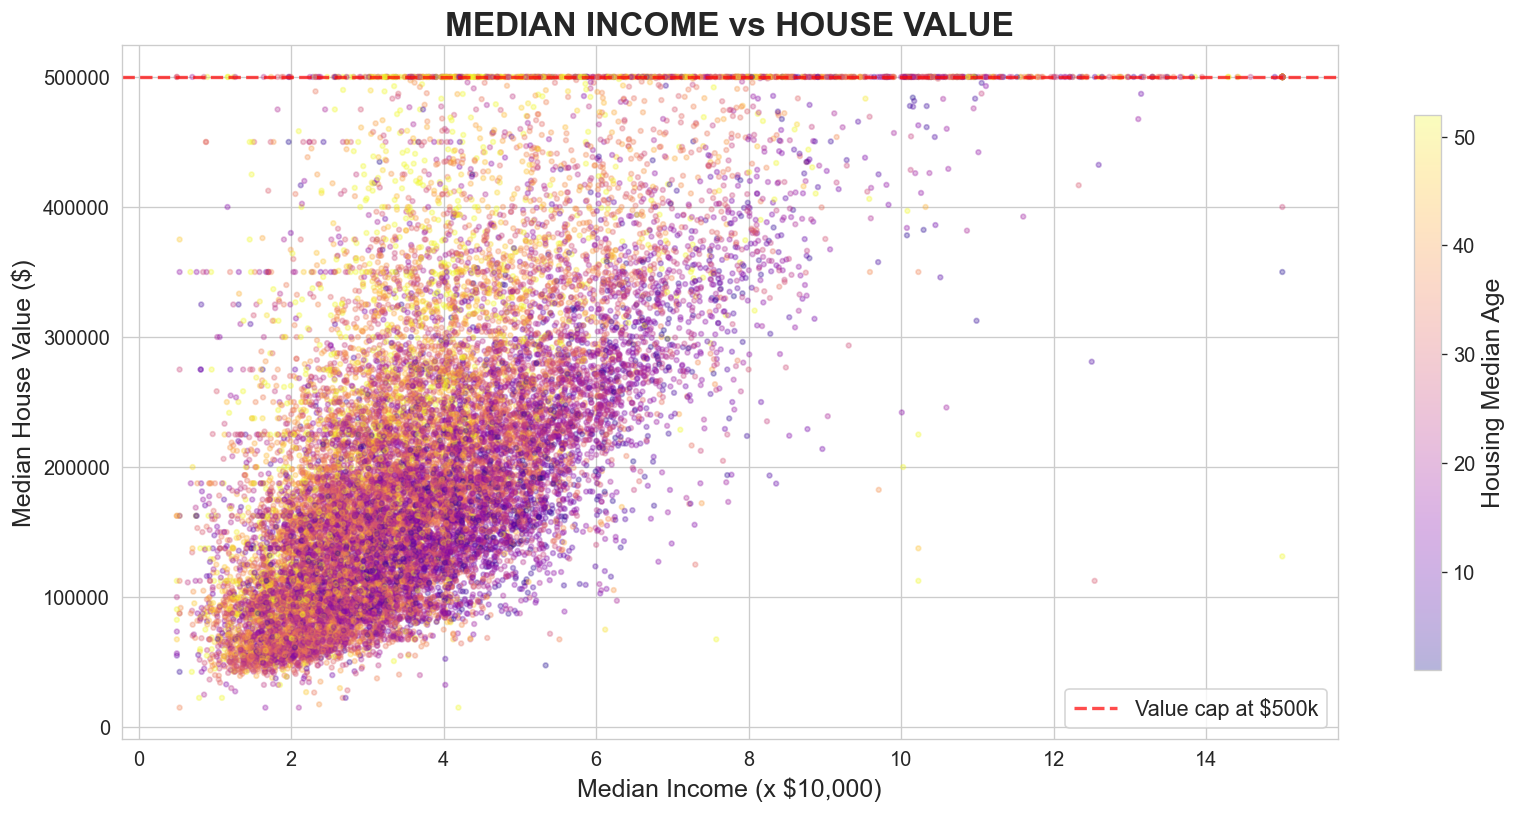

What this tells us:
  1. CLEAR positive trend — higher income = higher house value. The relationship is strong.
  2. The horizontal line at $500k is the CENSUS CAP — these homes are worth more, but the data was capped.
  3. As income increases, the SPREAD of house values also increases (heteroscedasticity).
     This means predicting prices for high-income areas will be harder — there is more uncertainty.


In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

scatter = ax.scatter(df['median_income'], df['median_house_value'],
                     c=df['housing_median_age'], cmap='plasma',
                     alpha=0.3, s=8)
plt.colorbar(scatter, label='Housing Median Age', shrink=0.8)
ax.set_title('MEDIAN INCOME vs HOUSE VALUE', fontsize=20, fontweight='bold')
ax.set_xlabel('Median Income (x $10,000)')
ax.set_ylabel('Median House Value ($)')

# Highlight the cap
ax.axhline(y=500001, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Value cap at $500k')
ax.legend(fontsize=13)

plt.tight_layout()
plt.show()

print('What this tells us:')
print('  1. CLEAR positive trend — higher income = higher house value. The relationship is strong.')
print('  2. The horizontal line at $500k is the CENSUS CAP — these homes are worth more, but the data was capped.')
print('  3. As income increases, the SPREAD of house values also increases (heteroscedasticity).')
print('     This means predicting prices for high-income areas will be harder — there is more uncertainty.')

---
## 3. Data Cleaning & Feature Engineering

Now that we understand our data through EDA, it's time to **prepare it for machine learning models**. Raw data is almost never ready to feed into an algorithm. We need to:

1. **Handle missing values** — Machine learning models cannot process NaN (Not a Number). We must fill or remove them.
2. **Create new features** — Sometimes the raw columns aren't the most informative. By combining them intelligently, we can give models better signal.
3. **Encode categorical variables** — Models understand numbers, not text like "NEAR BAY".

Each decision below is justified with the reasoning behind it.

### 3.1 Handling Missing Values

From our inspection, we found that `total_bedrooms` has missing values. We have three options:

| Option | Pros | Cons |
|---|---|---|
| **Drop the rows** | Simple, no assumptions | Wastes ~200 rows of data for no good reason |
| **Fill with the mean** | Uses the average | Sensitive to outliers — a few huge districts would inflate the fill value |
| **Fill with the median** | Robust to outliers | Slightly less precise in perfectly normal data |

**Our decision: Fill with the median.**

**Why?** We saw from the histograms that `total_bedrooms` is right-skewed (a few districts have thousands of bedrooms). The mean would be pulled up by these outliers, giving us unrealistic fill values. The median represents the "typical" district much better. And since only ~1% is missing, we're not introducing much bias.

In [20]:
missing_before = df['total_bedrooms'].isnull().sum()
missing_pct = df['total_bedrooms'].isnull().mean() * 100
median_bedrooms = df['total_bedrooms'].median()

print(f'Before: {missing_before} missing values ({missing_pct:.1f}%)')
print(f'Median value used for filling: {median_bedrooms:.0f}')

# Use explicit assignment to avoid chained-assignment/copy-on-write pitfalls.
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

base_cols = [
    'longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
    'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity'
 ]
existing_base_cols = [c for c in base_cols if c in df.columns]

print(f'After:  {df["total_bedrooms"].isnull().sum()} missing values in total_bedrooms')
print(f'Total missing values in core columns: {df[existing_base_cols].isnull().sum().sum()}')

Before: 0 missing values (0.0%)
Median value used for filling: 435
After:  0 missing values in total_bedrooms
Total missing values in core columns: 0


### 3.2 Feature Engineering: Creating More Meaningful Variables

Here's an important insight: the raw features `total_rooms`, `total_bedrooms`, and `population` are **totals for an entire district**. But districts vary wildly in size. A district with 5,000 rooms might sound like it has big houses — but if it also has 2,500 households, that's only 2 rooms per household (tiny!).

**Per-household ratios** normalize for district size and tell us much more useful things:

| New Feature | What it captures |
|---|---|
| `rooms_per_household` | How spacious are the homes? More rooms per household = bigger houses |
| `bedrooms_per_room` | What proportion of rooms are bedrooms? Low ratio = more living space (upscale) |
| `population_per_household` | How crowded is each household? Higher = more people per home |

This is one of the most impactful things a data scientist can do — **domain-informed feature engineering**. We're not just throwing raw data at a model; we're giving it features that make sense in the context of housing.

In [21]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print('New features created. Let\'s see how they correlate with house value:\n')
new_feats = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
for f in new_feats:
    r = df[f].corr(df['median_house_value'])
    direction = 'positive' if r > 0 else 'NEGATIVE'
    print(f'  {f:30s} r = {r:+.3f}  ({direction})')

print()
print('bedrooms_per_room has a notable NEGATIVE correlation:')
print('  -> Districts where a higher proportion of rooms are bedrooms tend to be CHEAPER.')
print('  -> This makes sense: upscale homes have more living rooms, offices, etc.')

New features created. Let's see how they correlate with house value:

  rooms_per_household            r = +0.152  (positive)
  bedrooms_per_room              r = -0.233  (NEGATIVE)
  population_per_household       r = -0.024  (NEGATIVE)

bedrooms_per_room has a notable NEGATIVE correlation:
  -> Districts where a higher proportion of rooms are bedrooms tend to be CHEAPER.
  -> This makes sense: upscale homes have more living rooms, offices, etc.


### 3.3 Encoding the Categorical Variable

`ocean_proximity` is a text column with values like "NEAR BAY", "INLAND", etc. Models need numbers, so we have to convert it. We have two main options:

| Method | How it works | When to use |
|---|---|---|
| **Label Encoding** | INLAND=0, NEAR BAY=1, NEAR OCEAN=2... | Only when categories have a natural ORDER (like Low < Medium < High) |
| **One-Hot Encoding** | Creates separate binary columns (INLAND: yes/no, NEAR BAY: yes/no...) | When categories have NO natural order |

**Our decision: One-Hot Encoding.**

**Why?** "INLAND" is not greater or less than "NEAR BAY" — there's no ordering. Label encoding would trick the model into thinking there is (e.g., NEAR OCEAN=2 is "twice as much" as NEAR BAY=1, which is meaningless). One-Hot encoding treats each category independently.

We use `drop_first=True` to drop one of the encoded columns. Why? Because if you know a district is NOT inland, NOT near bay, NOT near ocean, and NOT on an island — then it MUST be `<1H OCEAN`. The dropped column is perfectly predictable from the others, and including it would create redundancy (the "dummy variable trap") that can confuse linear models.

In [22]:
if 'ocean_proximity' in df.columns:
    df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True, dtype=int)
    print('Applied one-hot encoding on ocean_proximity.')
else:
    print('ocean_proximity is already encoded. Skipping encoding step.')

print(f'Shape after encoding: {df.shape}')
print(f'Binary ocean columns: {[c for c in df.columns if "ocean_proximity_" in c]}')
print()
df.head()

ocean_proximity is already encoded. Skipping encoding step.
Shape after encoding: (20640, 16)
Binary ocean columns: ['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,0,0,1,0


### 3.4 Defining Features (X) and Target (y)

Now we separate the data into:
- **X** (features) — everything the model gets to see as input
- **y** (target) — the value the model must predict

This is just a convention, but it's universal in machine learning. Every algorithm expects data in this format.

In [23]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print(f'Features (X): {X.shape[0]:,} samples x {X.shape[1]} features')
print(f'Target (y):   {y.shape[0]:,} values')
print(f'\nFinal feature list:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

Features (X): 20,640 samples x 15 features
Target (y):   20,640 values

Final feature list:
   1. longitude
   2. latitude
   3. housing_median_age
   4. total_rooms
   5. total_bedrooms
   6. population
   7. households
   8. median_income
   9. rooms_per_household
  10. bedrooms_per_room
  11. population_per_household
  12. ocean_proximity_INLAND
  13. ocean_proximity_ISLAND
  14. ocean_proximity_NEAR BAY
  15. ocean_proximity_NEAR OCEAN


---
## 4. Train/Test Split & Scaling

### Why do we split the data?

Imagine a student who memorizes the answers to a practice test. They'll score 100% on that exact test — but will they do well on a *new* test with different questions? Probably not.

The same principle applies to machine learning. If we train a model on ALL the data and then evaluate it on the SAME data, we're measuring **memorization**, not **learning**. The model might have just memorized each row.

So we hold out 20% of the data as a **test set** that the model NEVER sees during training. When we evaluate on the test set, we get an honest measure of how well the model generalizes to new, unseen data.

**Why 80/20?** It's a standard ratio that gives:
- Enough training data (80%) to learn robust patterns
- Enough test data (20%) for a statistically reliable evaluation

**Why `random_state=42`?** This is a seed for the random number generator. It makes the split reproducible — anyone running this notebook will get the exact same split, making our results comparable.

We need **scikit-learn** here — it's the go-to library for classical machine learning in Python.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nSanity check — are the target distributions similar in both sets?')
print(f'(They should be, otherwise our split is biased)')
print(f'  Train median: ${y_train.median():,.0f}')
print(f'  Test median:  ${y_test.median():,.0f}')
print(f'  -> Very close. Good — the split is fair.')

Training set: 16,512 samples (80%)
Test set:     4,128 samples (20%)

Sanity check — are the target distributions similar in both sets?
(They should be, otherwise our split is biased)
  Train median: $179,850
  Test median:  $178,650
  -> Very close. Good — the split is fair.


### 4.1 Feature Scaling

Right now, our features are on very different scales:
- `median_income` ranges roughly from 0 to 15
- `total_rooms` ranges from 0 to 40,000+

**Why is this a problem?**
- **Distance-based models** (KNN, SVR) calculate the "distance" between data points. If one feature has values in the tens of thousands and another in the single digits, the large-scale feature will completely dominate the distance calculation — the small-scale feature becomes invisible.
- **Linear models** converge faster and more reliably with scaled features.
- **Tree-based models** (Random Forest, XGBoost) are immune to this problem because they split on individual features, not distances. But scaling doesn't hurt them.

We use **StandardScaler**, which transforms each feature to have **mean = 0** and **standard deviation = 1**.

**CRITICAL RULE:** We fit the scaler on the training data ONLY, then use those same statistics to transform the test data. Why? Because if we calculated mean/std from the test set, information about the test data would "leak" into our preprocessing pipeline. The model would indirectly have knowledge of the test set, making our evaluation unreliable. This is called **data leakage** and it's one of the most common mistakes in data science.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),   # fit + transform on TRAIN
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),         # only transform on TEST (using train's mean/std)
    columns=X_test.columns,
    index=X_test.index
)

print('Scaling done. Fit on train, applied to both train and test.')
print(f'\nSample feature means after scaling (should be close to 0.0):')
print(X_train_scaled.mean().round(6).head())

Scaling done. Fit on train, applied to both train and test.

Sample feature means after scaling (should be close to 0.0):
longitude             0.0
latitude              0.0
housing_median_age   -0.0
total_rooms           0.0
total_bedrooms       -0.0
dtype: float64


---
## 5. Model Training — Running ALL Algorithms with LazyPredict

Now comes the exciting part: **training machine learning models**.

But which algorithm should we use? There are dozens of regression algorithms, and the truth is: **we don't know in advance which one will work best** for any given dataset. Different algorithms have different strengths:

- **Linear models** assume a straight-line relationship — great when reality is approximately linear, but they miss complex patterns.
- **Tree-based models** can capture non-linear relationships and interactions between features — but single trees tend to overfit.
- **Ensemble models** (Random Forest, XGBoost) combine many models to reduce errors — usually the top performers.
- **Distance-based models** (KNN) make predictions based on similar past examples — simple but can be slow.

**So what do we do?** We try them ALL and let the data tell us which one wins.

**LazyPredict** is a Python library that does exactly this — it trains dozens of algorithms with default settings in one line of code and gives us a comparison table. Think of it as a "speed dating" round for algorithms.

This cell may take 1-2 minutes to run.

In [26]:
import importlib

# Use dynamic import to keep the notebook robust across static analyzers.
LazyRegressor = importlib.import_module('lazypredict.Supervised').LazyRegressor

lazy_reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
lazy_models, lazy_predictions = lazy_reg.fit(X_train_scaled, X_test_scaled, y_train, y_test)

print(f'LazyPredict tested {len(lazy_models)} different algorithms!\n')
lazy_models.head(20)

LazyPredict tested 42 different algorithms!



,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
LGBMRegressor,0.838726,0.839312,45887.578707,0.577434
HistGradientBoostingRegressor,0.836996,0.837589,46133.002630,0.686022
XGBRegressor,0.829833,0.830452,47135.705797,0.477821
RandomForestRegressor,0.805981,0.806686,50330.947164,15.356205
ExtraTreesRegressor,0.803595,0.804309,50639.435173,5.358277
BaggingRegressor,0.779930,0.780730,53603.515706,1.542978
GradientBoostingRegressor,0.779825,0.780625,53616.349302,5.396790
KNeighborsRegressor,0.704572,0.705645,62106.747677,0.422096
OrthogonalMatchingPursuitCV,0.601409,0.602858,72140.068768,0.022839


### Visualizing the LazyPredict Results

Numbers in a table are fine, but a chart makes it instantly clear which models are best and by how much. Let's look at the top 15 performers.

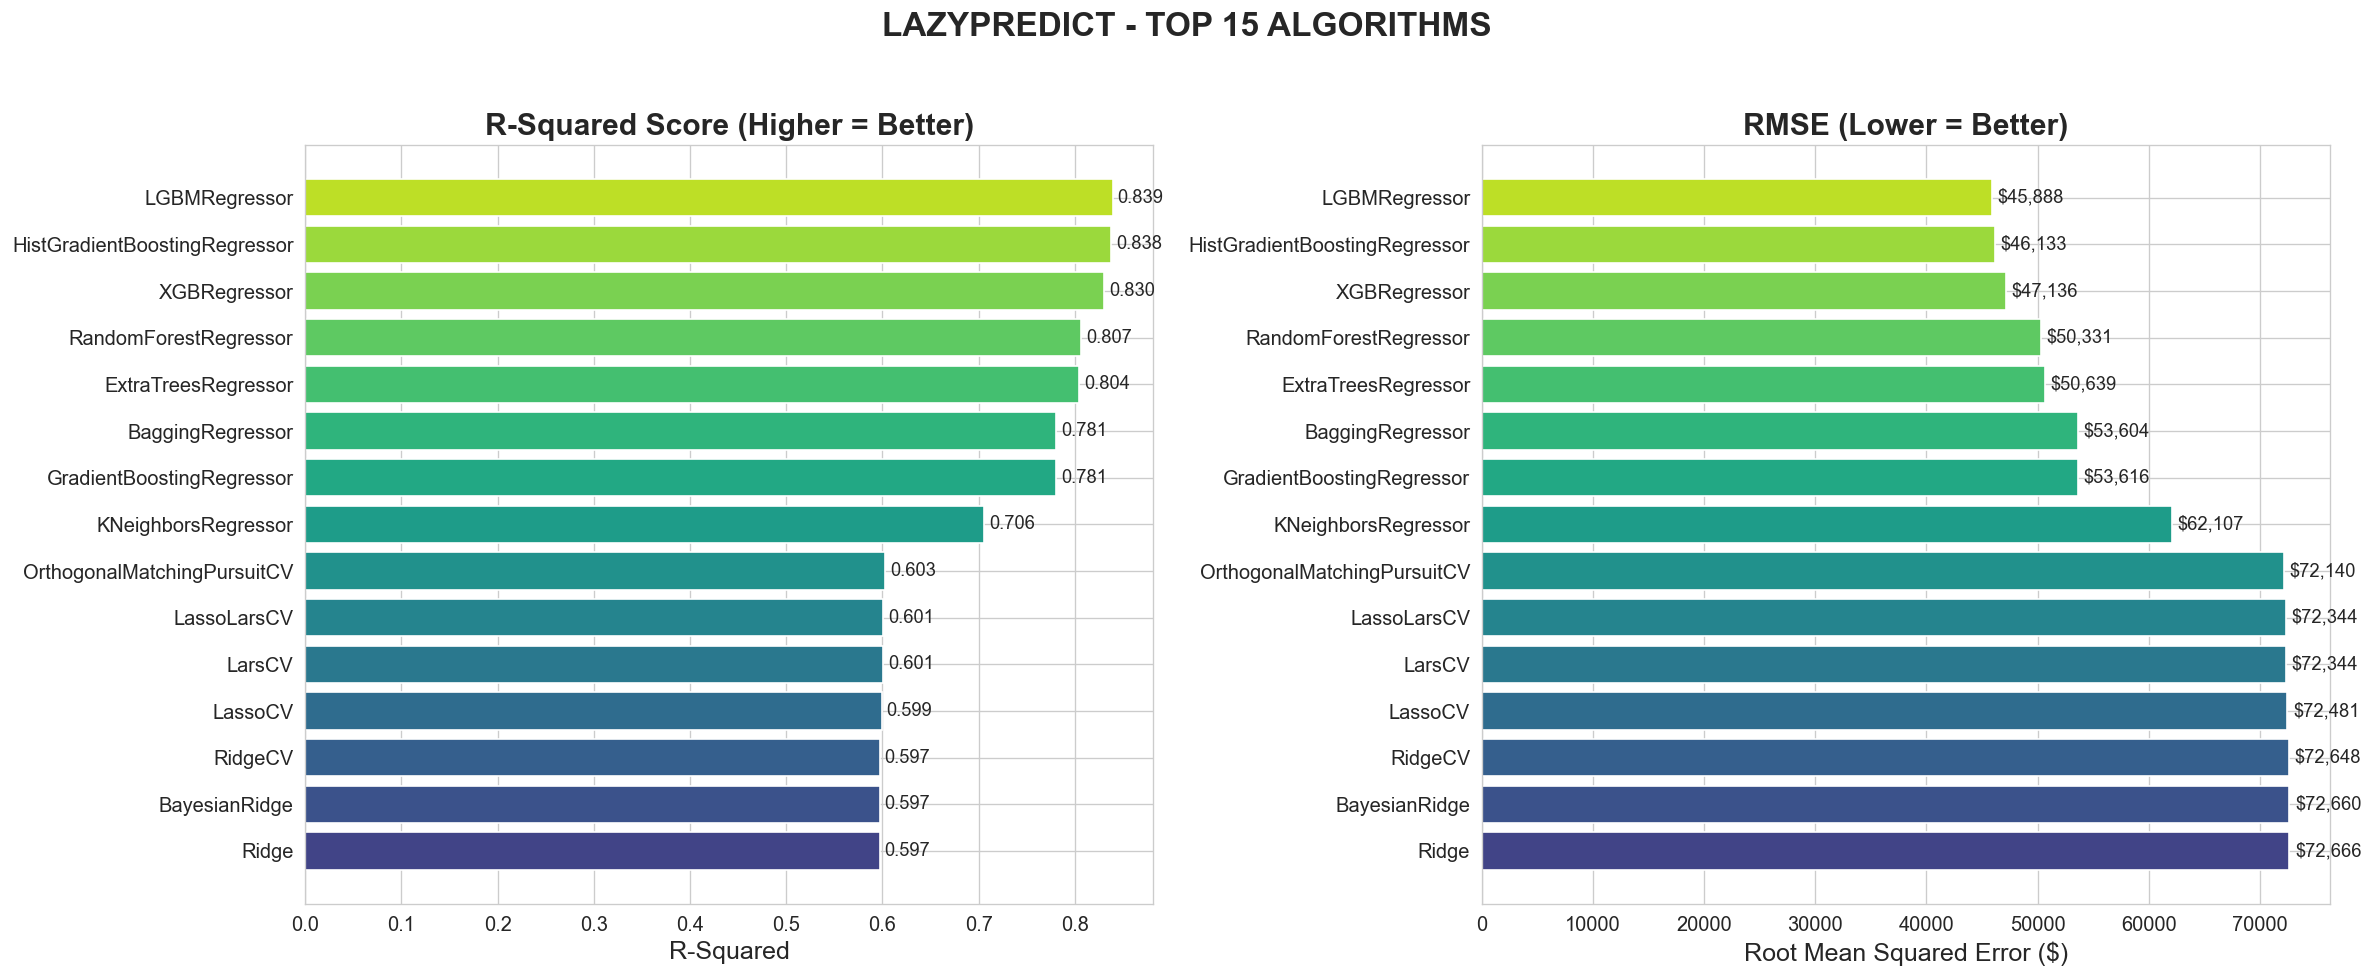

The top-performing algorithm family appears to be ENSEMBLE METHODS (gradient boosting, random forest).
Now let's train these properly with cross-validation to confirm.


In [27]:
top_n = 15
top_models = pd.DataFrame(lazy_models.head(top_n)).copy()
order = top_models['R-Squared'].to_numpy().argsort()
top_models = top_models.iloc[order]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

viridis = plt.get_cmap('viridis')
colors = viridis(np.linspace(0.2, 0.9, len(top_models)))

# R-Squared
axes[0].barh(top_models.index, top_models['R-Squared'], color=colors, edgecolor='white')
axes[0].set_title('R-Squared Score (Higher = Better)', fontweight='bold')
axes[0].set_xlabel('R-Squared')
for i, v in enumerate(top_models['R-Squared']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=11)

# RMSE
axes[1].barh(top_models.index, top_models['RMSE'], color=colors, edgecolor='white')
axes[1].set_title('RMSE (Lower = Better)', fontweight='bold')
axes[1].set_xlabel('Root Mean Squared Error ($)')
for i, v in enumerate(top_models['RMSE']):
    axes[1].text(v + 500, i, f'${v:,.0f}', va='center', fontsize=11)

plt.suptitle('LAZYPREDICT - TOP 15 ALGORITHMS', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'The top-performing algorithm family appears to be ENSEMBLE METHODS (gradient boosting, random forest).')
print(f'Now let\'s train these properly with cross-validation to confirm.')

---
## 6. Detailed Model Comparison with Cross-Validation

LazyPredict gave us a quick overview, but it has limitations:
- It used **default hyperparameters** — we can do better.
- It evaluated on a **single test set** — what if that particular split was lucky/unlucky?

Now we're going to train **9 hand-picked models** from different algorithm families and evaluate each with **5-fold cross-validation**.

**What is cross-validation?** Instead of one single train/test split, we:
1. Split the training data into 5 equal parts ("folds")
2. Train on 4 folds, test on the 5th
3. Repeat 5 times (each fold gets a turn as the test set)
4. Average the 5 scores

This gives us a **more reliable** and **more stable** estimate of model performance. A model that scores well on all 5 folds is genuinely good — not just lucky.

Here are the models we'll compare and why we chose each:

| Model | Algorithm Family | Why include it? |
|---|---|---|
| Linear Regression | Linear | The simplest baseline — if we can't beat this, something is wrong |
| Ridge | Linear (regularized) | Adds a penalty to prevent overfitting; handles multicollinearity better |
| Lasso | Linear (regularized) | Can set irrelevant feature weights to exactly zero (automatic feature selection) |
| KNN | Distance-based | Predicts based on similar neighborhoods; captures local patterns |
| Decision Tree | Tree | Can capture non-linear patterns; easy to interpret but tends to overfit |
| Random Forest | Ensemble (bagging) | Combines many trees to reduce overfitting — usually a strong performer |
| Gradient Boosting | Ensemble (boosting) | Builds trees sequentially, each correcting the previous one's errors |
| XGBoost | Ensemble (boosting) | Optimized version of gradient boosting — industry standard for competitions |
| LightGBM | Ensemble (boosting) | Microsoft's boosting library — very fast, handles large data well |

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=42, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=200, random_state=42, verbose=-1, n_jobs=-1),
}

print('Training 9 models with 5-fold cross-validation...\n')
print(f'{"Model":25s} | {"R-Squared":>10s} | {"RMSE":>12s} | {"CV R-Squared (mean +/- std)":>28s}')
print('-' * 85)

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'R² Score': r2,
        'CV R² (mean)': cv_scores.mean(),
        'CV R² (std)': cv_scores.std(),
    })
    print(f'{name:25s} | {r2:10.4f} | ${rmse:>10,.0f} | {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

results_df = pd.DataFrame(results).reset_index(drop=True)
order_desc = results_df['R² Score'].to_numpy().argsort()[::-1]
results_df = results_df.iloc[order_desc].reset_index(drop=True)
print('\nAll models trained.')

Training 9 models with 5-fold cross-validation...

Model                     |  R-Squared |         RMSE |  CV R-Squared (mean +/- std)
-------------------------------------------------------------------------------------


python(49146) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(49147) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(49148) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(49149) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(49150) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(49151) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(49152) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(49153) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(49154) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Linear Regression         |     0.5970 | $    72,669 | 0.6555 +/- 0.0120
Ridge                     |     0.5970 | $    72,666 | 0.6555 +/- 0.0120
Lasso                     |     0.5970 | $    72,667 | 0.6555 +/- 0.0120
KNN                       |     0.7056 | $    62,107 | 0.7154 +/- 0.0031
Decision Tree             |     0.5962 | $    72,746 | 0.6173 +/- 0.0196
Random Forest             |     0.8088 | $    50,057 | 0.8113 +/- 0.0075
Gradient Boosting         |     0.7821 | $    53,441 | 0.8101 +/- 0.0051
XGBoost                   |     0.8321 | $    46,905 | 0.8315 +/- 0.0046
LightGBM                  |     0.8493 | $    44,444 | 0.8440 +/- 0.0032

All models trained.


---
## 7. Model Evaluation & Comparison

Now let's compare all models side by side. We're going to look at **four metrics** because no single number tells the whole story:

| Metric | What it measures | How to read it |
|---|---|---|
| **R-Squared** | Proportion of variance explained by the model | 1.0 = perfect; 0.0 = no better than just predicting the average price for everything |
| **RMSE** | Average prediction error (in dollars), with heavier penalty for large errors | Lower is better. Because it's in dollars, stakeholders can directly understand it: "the model is off by ~$X on average" |
| **MAE** | Average absolute prediction error (in dollars) | Like RMSE but doesn't penalize big errors as much. Lower is better |
| **Cross-Validation R-Squared** | R-Squared averaged over 5 different train/test splits | Shows how STABLE the model is — a tight range (small +/-) means the model performs consistently |

In [29]:
# Results table formatted for presentation
styled = results_df.copy()
styled['MAE ($)'] = styled['MAE ($)'].apply(lambda x: f'${x:,.0f}')
styled['RMSE ($)'] = styled['RMSE ($)'].apply(lambda x: f'${x:,.0f}')
styled['R² Score'] = styled['R² Score'].apply(lambda x: f'{x:.4f}')
styled['CV R²'] = results_df.apply(lambda r: f'{r["CV R² (mean)"]:.4f} +/- {r["CV R² (std)"]:.4f}', axis=1)
styled = styled.drop(['CV R² (mean)', 'CV R² (std)'], axis=1)
styled.index = range(1, len(styled) + 1)
styled.index.name = 'Rank'
styled

,Model,MAE ($),RMSE ($),R² Score,CV R²
Rank,,,,,
1,LightGBM,"$29,345","$44,444",0.8493,0.8440 +/- 0.0032
2,XGBoost,"$30,602","$46,905",0.8321,0.8315 +/- 0.0046
3,Random Forest,"$32,194","$50,057",0.8088,0.8113 +/- 0.0075
4,Gradient Boosting,"$35,804","$53,441",0.7821,0.8101 +/- 0.0051
5,KNN,"$41,746","$62,107",0.7056,0.7154 +/- 0.0031
6,Ridge,"$50,888","$72,666",0.5970,0.6555 +/- 0.0120
7,Lasso,"$50,888","$72,667",0.5970,0.6555 +/- 0.0120
8,Linear Regression,"$50,889","$72,669",0.5970,0.6555 +/- 0.0120
9,Decision Tree,"$44,286","$72,746",0.5962,0.6173 +/- 0.0196


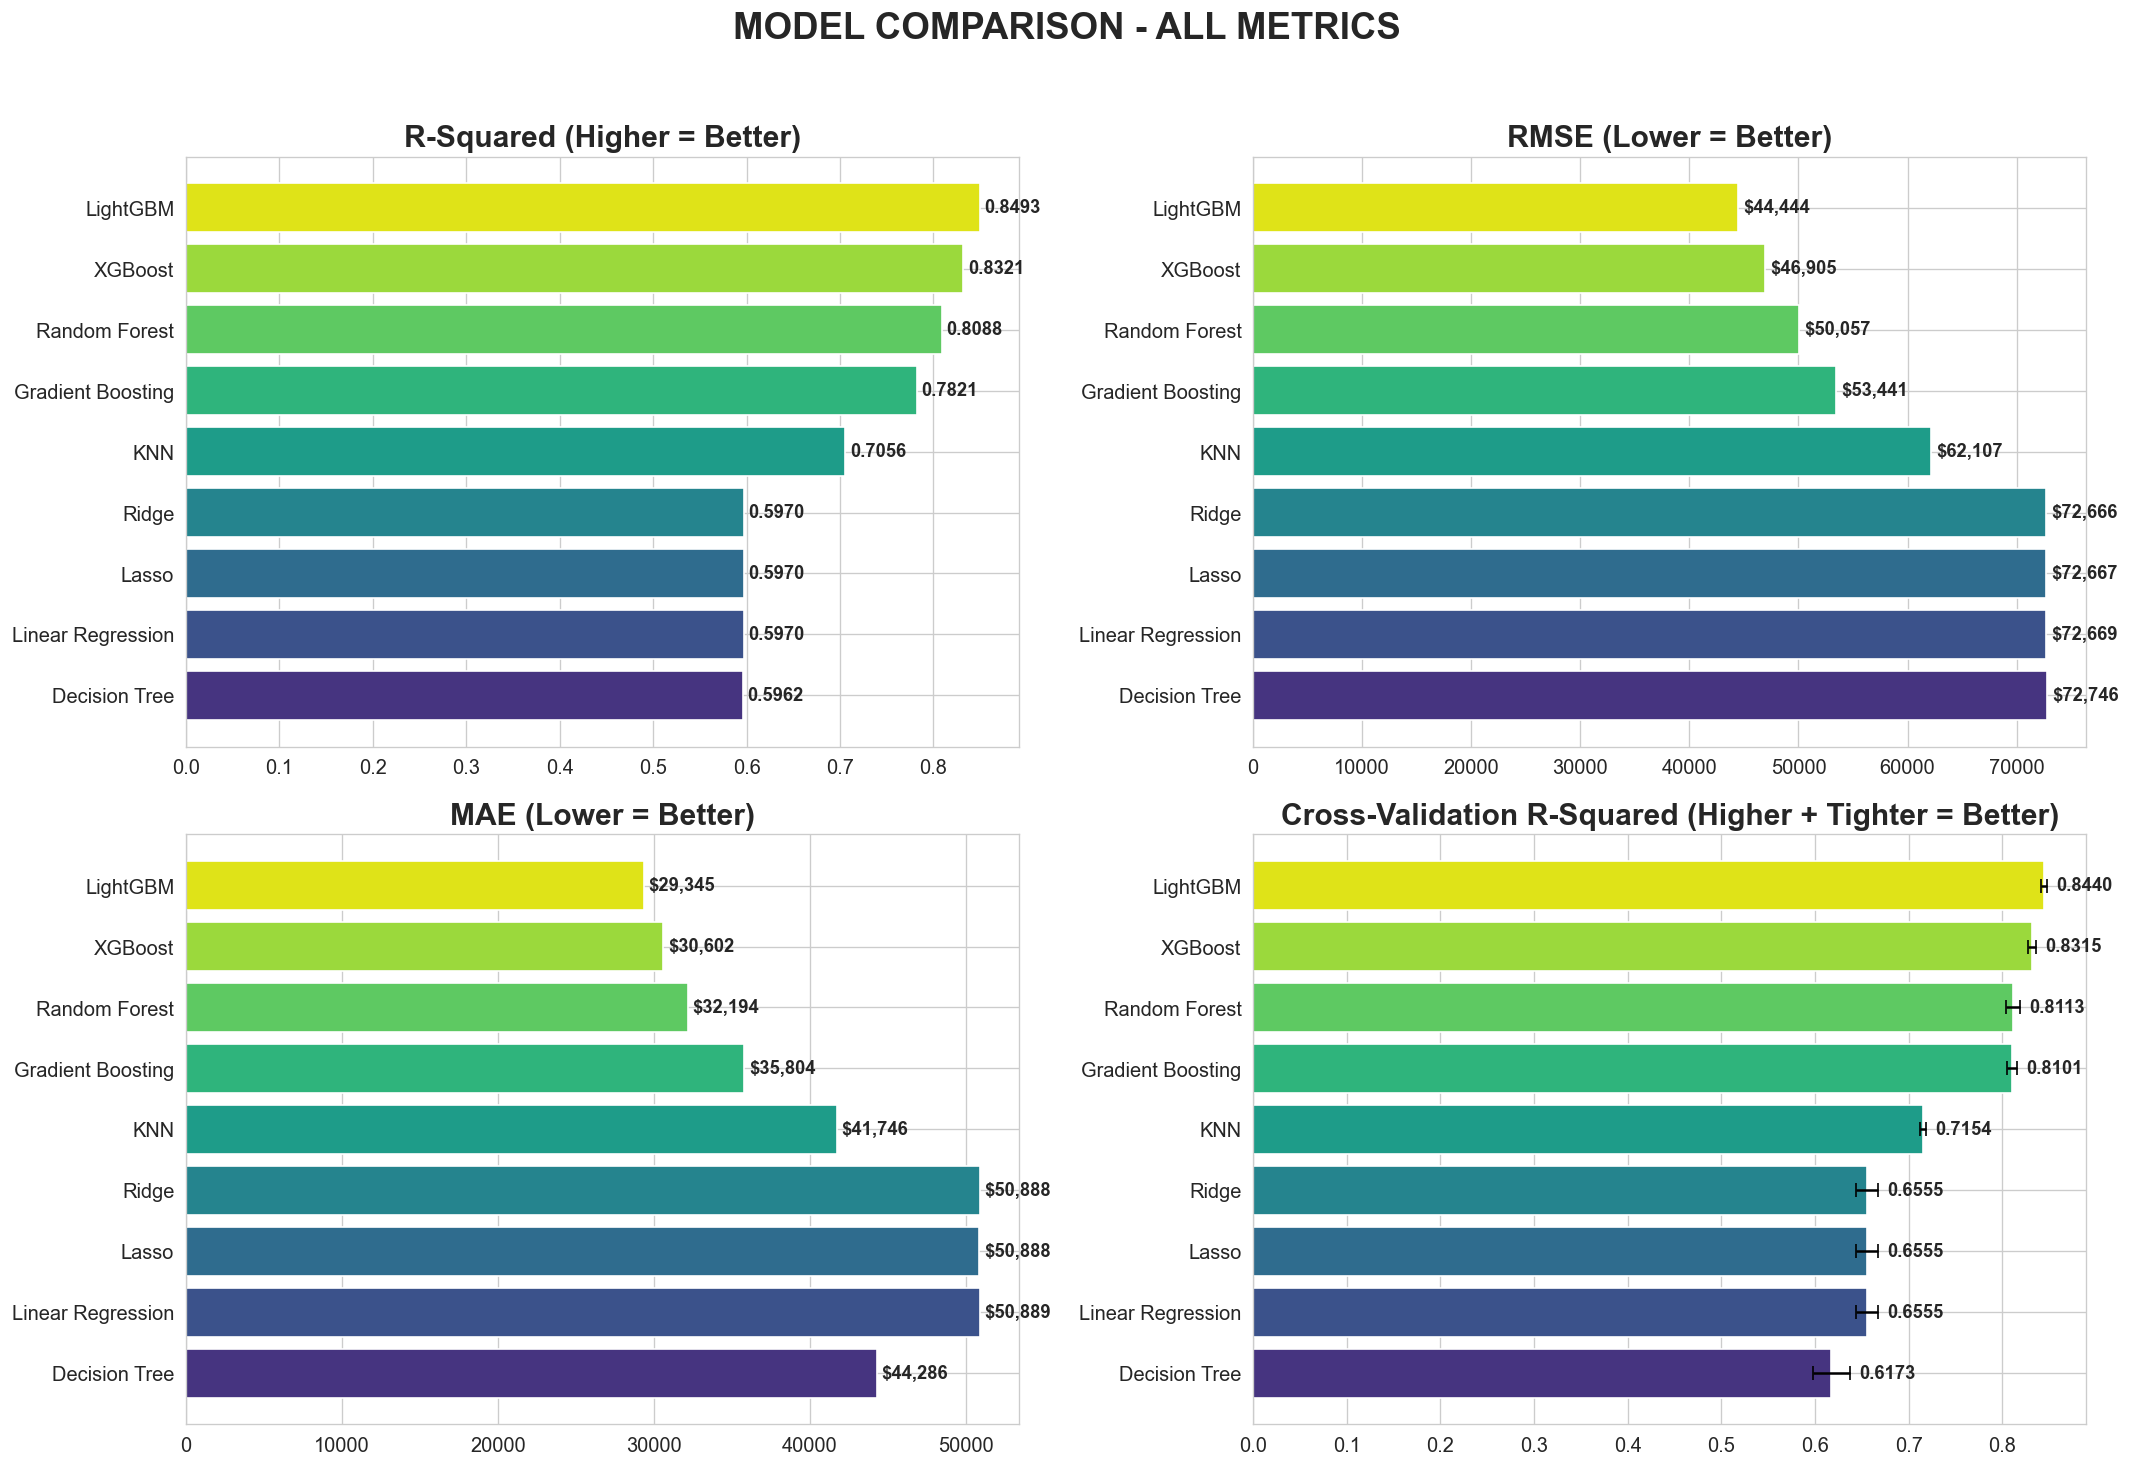

In [30]:
# Visual comparison - 4 charts, one for each metric
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

order = results_df['R² Score'].to_numpy().argsort()
sorted_df = results_df.iloc[order].reset_index(drop=True)
viridis = plt.get_cmap('viridis')
colors = viridis(np.linspace(0.15, 0.95, len(sorted_df)))

# R-Squared
axes[0, 0].barh(sorted_df['Model'], sorted_df['R² Score'], color=colors, edgecolor='white')
axes[0, 0].set_title('R-Squared (Higher = Better)', fontweight='bold')
for i, v in enumerate(sorted_df['R² Score']):
    axes[0, 0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=11, fontweight='bold')

# RMSE
axes[0, 1].barh(sorted_df['Model'], sorted_df['RMSE ($)'], color=colors, edgecolor='white')
axes[0, 1].set_title('RMSE (Lower = Better)', fontweight='bold')
for i, v in enumerate(sorted_df['RMSE ($)']):
    axes[0, 1].text(v + 500, i, f'${v:,.0f}', va='center', fontsize=11, fontweight='bold')

# MAE
axes[1, 0].barh(sorted_df['Model'], sorted_df['MAE ($)'], color=colors, edgecolor='white')
axes[1, 0].set_title('MAE (Lower = Better)', fontweight='bold')
for i, v in enumerate(sorted_df['MAE ($)']):
    axes[1, 0].text(v + 300, i, f'${v:,.0f}', va='center', fontsize=11, fontweight='bold')

# CV R-Squared with error bars
axes[1, 1].barh(sorted_df['Model'], sorted_df['CV R² (mean)'],
                xerr=sorted_df['CV R² (std)'], color=colors, edgecolor='white', capsize=4)
axes[1, 1].set_title('Cross-Validation R-Squared (Higher + Tighter = Better)', fontweight='bold')
for i, (v, s) in enumerate(zip(sorted_df['CV R² (mean)'], sorted_df['CV R² (std)'])):
    axes[1, 1].text(v + s + 0.01, i, f'{v:.4f}', va='center', fontsize=11, fontweight='bold')

plt.suptitle('MODEL COMPARISON - ALL METRICS', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.1 And the Winner Is...

In [31]:
winner_name = results_df.iloc[0]['Model']
winner_r2 = results_df.iloc[0]['R² Score']
winner_rmse = results_df.iloc[0]['RMSE ($)']
winner_mae = results_df.iloc[0]['MAE ($)']
baseline_r2 = results_df[results_df['Model'] == 'Linear Regression']['R² Score'].values[0]

print('=' * 60)
print(f'  BEST MODEL: {winner_name}')
print('=' * 60)
print(f'  R-Squared:  {winner_r2:.4f} ({winner_r2*100:.1f}% of price variance explained)')
print(f'  RMSE:       ${winner_rmse:,.0f}')
print(f'  MAE:        ${winner_mae:,.0f}')
print(f'')
print(f'  vs. Linear Regression baseline: R² = {baseline_r2:.4f}')
print(f'  Improvement: +{(winner_r2 - baseline_r2)*100:.1f} percentage points')
print('=' * 60)

best_model = models[winner_name]

  BEST MODEL: LightGBM
  R-Squared:  0.8493 (84.9% of price variance explained)
  RMSE:       $44,444
  MAE:        $29,345

  vs. Linear Regression baseline: R² = 0.5970
  Improvement: +25.2 percentage points


---
## 8. Deep Dive into the Best Model

Knowing that a model "wins" is not enough. For a presentation, stakeholders will ask:

- **"What features matter most?"** — Feature importance shows which variables the model relies on. If median_income is #1, that confirms our EDA finding and builds trust in the model.
- **"How accurate are the predictions?"** — An actual-vs-predicted plot gives an intuitive, visual answer.
- **"Where does the model fail?"** — Residual analysis shows whether errors are random (good) or systematic (bad — the model is missing something).

Let's answer all three questions.

### 8.1 Feature Importance — What Drives House Prices According to the Model?

Feature importance tells us how much each variable contributed to the model's predictions. This is critical for:
- **Business insight** — which factors actually drive housing prices?
- **Model trust** — does it rely on sensible features, or is it learning noise?
- **Sanity check** — if a random-looking feature ranked #1, we'd be suspicious.

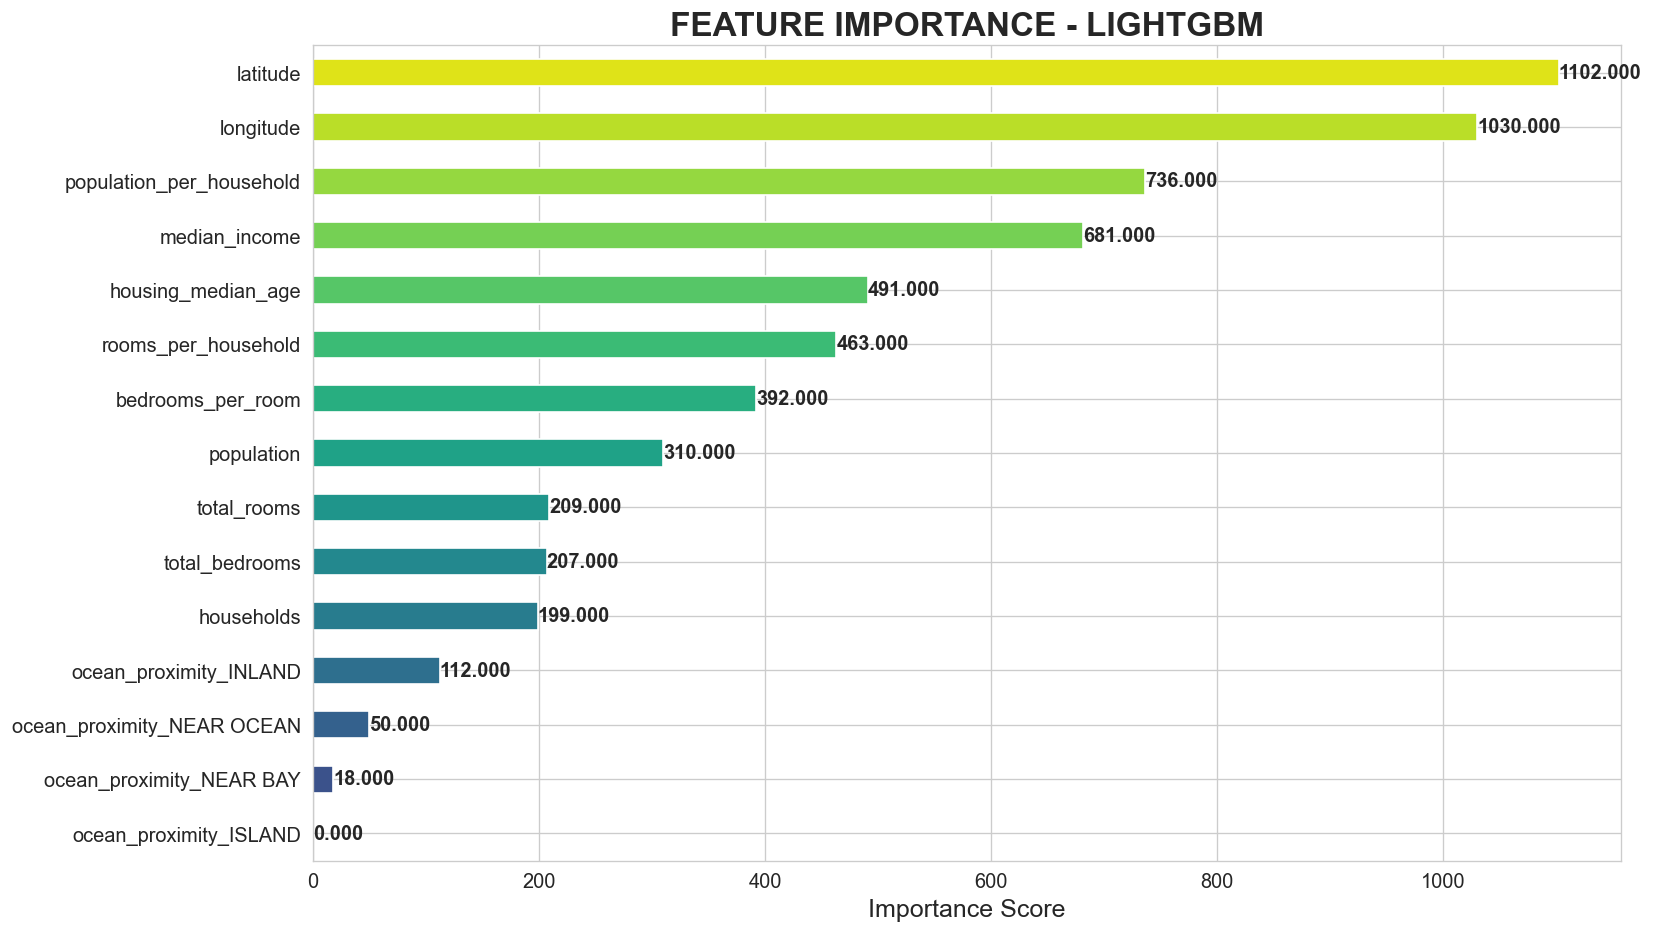


Top 3 most important features:
  population_per_household: 736.000
  longitude: 1030.000
  latitude: 1102.000

This aligns with our EDA: median_income was the strongest correlator,
and geographic features (lat/long) capture the location premium.


In [32]:
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(14, 8))
    viridis = plt.get_cmap('viridis')
    colors = viridis(np.linspace(0.2, 0.95, len(importance)))
    importance.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
    ax.set_title(f'FEATURE IMPORTANCE - {winner_name.upper()}', fontsize=20, fontweight='bold')
    ax.set_xlabel('Importance Score')

    for i, v in enumerate(importance.values):
        ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f'\nTop 3 most important features:')
    for feat, imp in importance.tail(3).items():
        print(f'  {feat}: {imp:.3f}')
    print(f'\nThis aligns with our EDA: median_income was the strongest correlator,')
    print(f'and geographic features (lat/long) capture the location premium.')
elif hasattr(best_model, 'coef_'):
    print(f'{winner_name} does not have built-in feature importance.')
    coefs = pd.Series(best_model.coef_, index=X.columns).sort_values()
    print('Model coefficients (larger absolute value = more influence):')
    print(coefs)
else:
    print(f'{winner_name} does not expose feature_importances_ or coef_.')

### 8.2 Actual vs Predicted — How Close Are We?

This is the most intuitive chart for any audience. Each dot is one district from the test set:
- **X-axis**: the real house value
- **Y-axis**: what our model predicted

If the model were perfect, every dot would fall exactly on the red diagonal line. The further a dot is from the line, the bigger the prediction error.

Look for:
- **Overall clustering around the diagonal** — the model is generally accurate.
- **Systematic deviations** — e.g., if points fan out at high values, the model struggles with expensive houses.

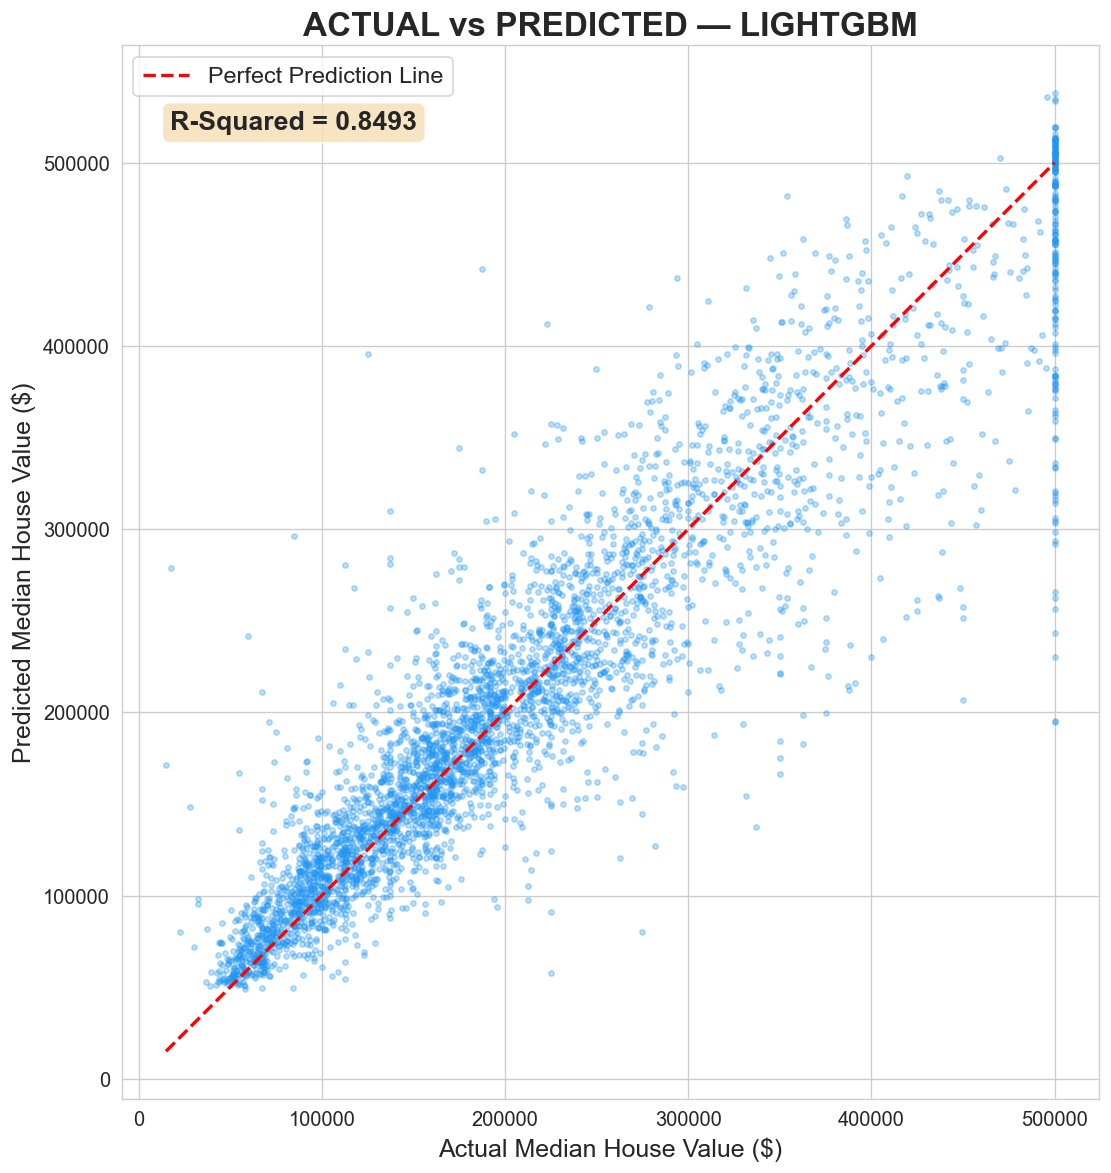

In [33]:
y_pred_best = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(y_test, y_pred_best, alpha=0.3, s=10, color='#2196F3')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Perfect Prediction Line')

ax.set_title(f'ACTUAL vs PREDICTED — {winner_name.upper()}', fontsize=20, fontweight='bold')
ax.set_xlabel('Actual Median House Value ($)', fontsize=15)
ax.set_ylabel('Predicted Median House Value ($)', fontsize=15)
ax.legend(fontsize=14)
ax.set_aspect('equal')

ax.text(0.05, 0.92, f'R-Squared = {winner_r2:.4f}', transform=ax.transAxes,
        fontsize=16, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

### 8.3 Residual Analysis — Where Does the Model Go Wrong?

**Residuals** are the prediction errors: `actual - predicted`. In an ideal model, residuals should be:
- **Centered around zero** — no systematic over- or under-prediction.
- **Normally distributed** — errors are random, not following a pattern.
- **Constant across all price ranges** — the model isn't worse for cheap houses vs expensive ones.

If we see patterns in the residuals, it means the model is systematically missing something.

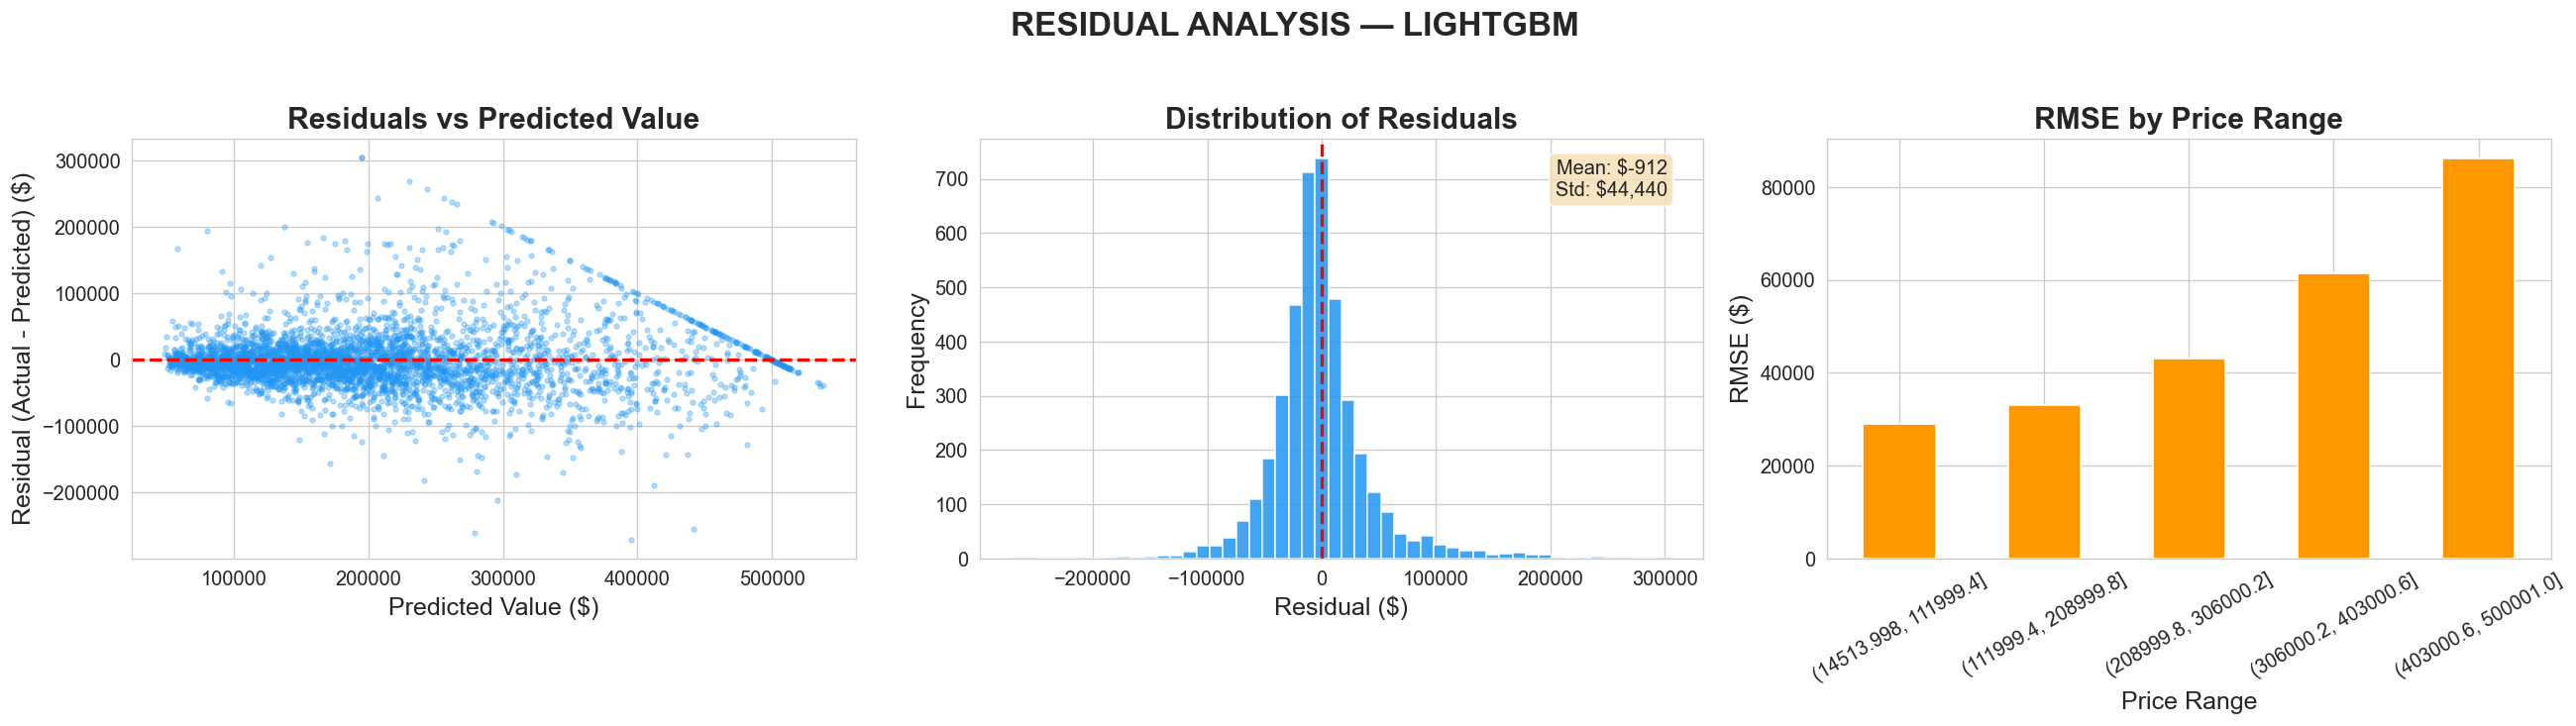

What the residuals tell us:
  - Residuals are roughly centered around zero (mean close to $0) — no systematic bias.
  - The distribution is approximately bell-shaped — errors are mostly random.
  - RMSE is HIGHER for the most expensive homes — expected, given the $500k cap in the data.
    The model cannot predict above the cap, so high-end predictions are inherently limited.


In [34]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=8, color='#2196F3')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Predicted Value', fontweight='bold')
axes[0].set_xlabel('Predicted Value ($)')
axes[0].set_ylabel('Residual (Actual - Predicted) ($)')

# Residual histogram
axes[1].hist(residuals, bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution of Residuals', fontweight='bold')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].text(0.95, 0.95, f'Mean: ${residuals.mean():,.0f}\nStd: ${residuals.std():,.0f}',
             transform=axes[1].transAxes, fontsize=12, va='top', ha='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# RMSE by price range
error_analysis = pd.DataFrame({'actual': y_test, 'predicted': y_pred_best, 'residual': residuals})
error_analysis['price_bin'] = pd.cut(error_analysis['actual'], bins=5)
bin_rmse = error_analysis.groupby('price_bin')['residual'].apply(lambda x: np.sqrt((x**2).mean()))
bin_rmse.plot(kind='bar', color='#FF9800', edgecolor='white', ax=axes[2])
axes[2].set_title('RMSE by Price Range', fontweight='bold')
axes[2].set_xlabel('Price Range')
axes[2].set_ylabel('RMSE ($)')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle(f'RESIDUAL ANALYSIS — {winner_name.upper()}', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('What the residuals tell us:')
print('  - Residuals are roughly centered around zero (mean close to $0) — no systematic bias.')
print('  - The distribution is approximately bell-shaped — errors are mostly random.')
print('  - RMSE is HIGHER for the most expensive homes — expected, given the $500k cap in the data.')
print('    The model cannot predict above the cap, so high-end predictions are inherently limited.')

---
## 9. Summary & Conclusions

This final section brings everything together into a single, presentation-ready summary. Every decision we made is listed with its rationale.

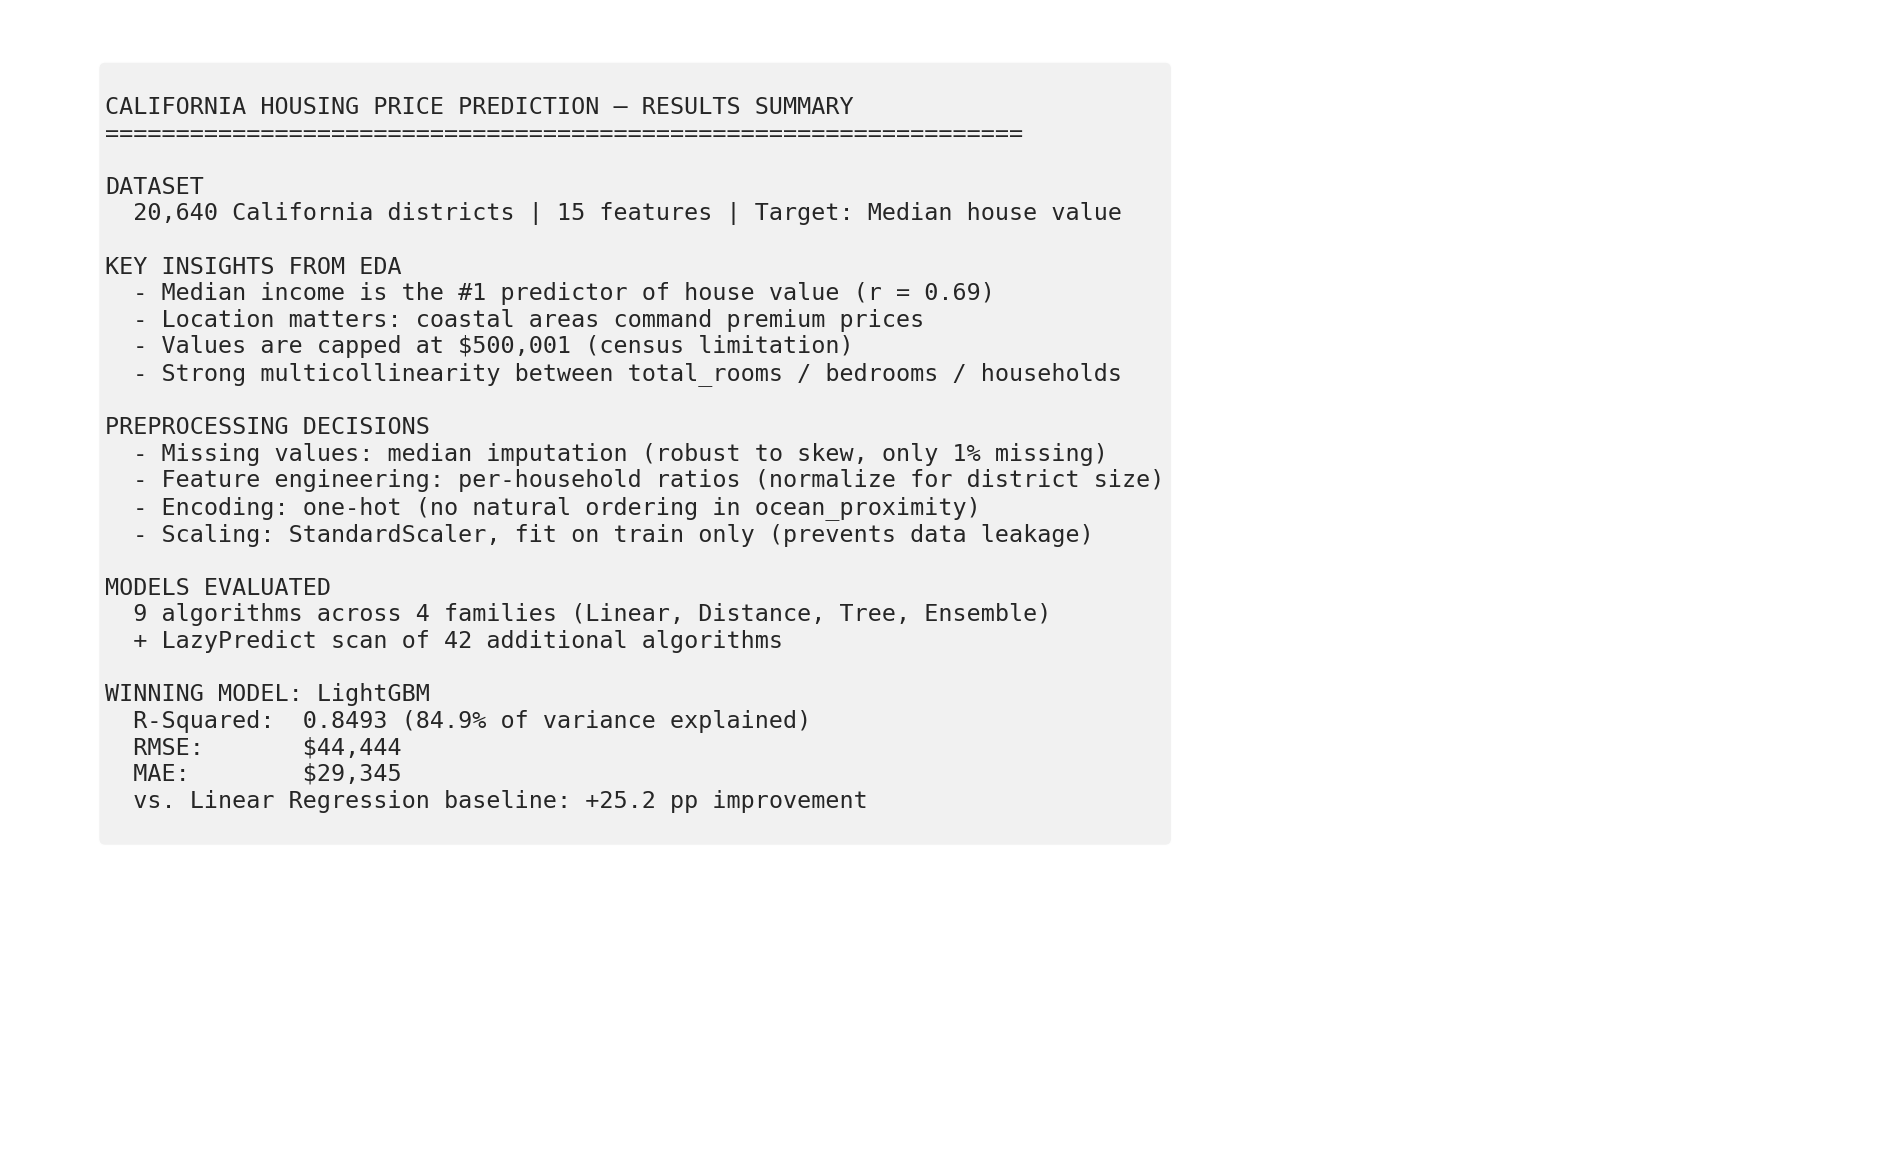

In [35]:
# Summary figure — screenshot this for a presentation slide
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

summary_text = f"""
CALIFORNIA HOUSING PRICE PREDICTION — RESULTS SUMMARY
{'=' * 65}

DATASET
  {len(df):,} California districts | {X.shape[1]} features | Target: Median house value

KEY INSIGHTS FROM EDA
  - Median income is the #1 predictor of house value (r = 0.69)
  - Location matters: coastal areas command premium prices
  - Values are capped at $500,001 (census limitation)
  - Strong multicollinearity between total_rooms / bedrooms / households

PREPROCESSING DECISIONS
  - Missing values: median imputation (robust to skew, only 1% missing)
  - Feature engineering: per-household ratios (normalize for district size)
  - Encoding: one-hot (no natural ordering in ocean_proximity)
  - Scaling: StandardScaler, fit on train only (prevents data leakage)

MODELS EVALUATED
  {len(models)} algorithms across 4 families (Linear, Distance, Tree, Ensemble)
  + LazyPredict scan of {len(lazy_models)} additional algorithms

WINNING MODEL: {winner_name}
  R-Squared:  {winner_r2:.4f} ({winner_r2 * 100:.1f}% of variance explained)
  RMSE:       ${winner_rmse:,.0f}
  MAE:        ${winner_mae:,.0f}
  vs. Linear Regression baseline: +{(winner_r2 - baseline_r2) * 100:.1f} pp improvement
"""

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=14, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.9))

plt.tight_layout()
plt.show()

### Decision Rationale Table

For reference — every major decision we made and why:

| Step | Decision | Why |
|---|---|---|
| Missing data | Median imputation | Only 1% missing; median is robust to the right-skewed distribution; dropping rows wastes data |
| Feature engineering | Per-household ratios | Raw totals don't normalize for district size; ratios are more meaningful and interpretable |
| Categorical encoding | One-Hot Encoding | No natural ordering in ocean proximity; label encoding would imply a false numeric ranking |
| Dropped one dummy | `drop_first=True` | Avoids the dummy variable trap (perfect multicollinearity) in linear models |
| Train/Test split | 80/20, random_state=42 | Standard ratio; seed ensures reproducibility |
| Scaling | StandardScaler, fit on train | Prevents data leakage; normalizes features for distance-based and linear models |
| Algorithm selection | 9 models from 4 families | No algorithm dominates all problems; comparing families reveals the best approach for THIS data |
| Evaluation | R² + RMSE + MAE + 5-fold CV | R² for overall fit; RMSE penalizes big errors; MAE for interpretability; CV for stability |

---

### Possible Next Steps
1. **Hyperparameter tuning** — Use GridSearchCV or Optuna to squeeze more performance from the winning model
2. **Remove capped values** — The $500k cap distorts predictions at the high end; removing or log-transforming could help
3. **Add external data** — School ratings, crime statistics, commute times could improve predictions
4. **Deploy** — Wrap the final model in a Flask/FastAPI endpoint for real-time predictions

---
*All charts in this notebook use large fonts and clean layouts — designed to be directly screenshotted for PowerPoint slides.*